# **Assessment 2: Kernel Ridge Regression on BoardGameGeek Ratings**
---
**Subject:** 31005 Machine Learning

**Assessment:** A2 Option 1, Study and Implementation of a Fundamental Machine Learning Model

**Model:** Kernel Ridge Regression (Radial Basis Function Kernel)

**Student Name:** Adam Cameron

**Student ID:** 14327074

### **Launch Options**
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Petheron/ML-A2-KRR/blob/main/Assessment_2.ipynb)
[![View on GitHub](https://img.shields.io/badge/GitHub-Repo-blue?logo=github)](https://github.com/Petheron/ML-A2-KRR)

## <ins>**0. Overview & I/O Contract**</ins>
This opening section establishes the problem setting, the precise interface between data and model (inputs, outputs, valid ranges, and cleaning), and the mathematical symbols used throughout the implementation notebook. It also provides a compact, reusable table printer to ensure consistent reporting across later sections.

The goal is to make assumptions explicit, and to ensure that all downstream computations are transparent and reproducible.

### **0.1. Task Definition**
This subsection formalises the predictive task and the high-level mapping from inputs to outputs, motivating the choice of Kernel Ridge Regression (KRR) with a Radial Basis Function (RBF) kernel.

##### *0.1.1. Objective*
Predict the **average BoardGameGeek (BGG) user rating** on a 1–10 scale for a board game, using core numeric attributes drawn from a curated CSV (bundled with the submission or available on this project's public GitHub repository). 

This is a **supervised regression** task.

##### *0.1.2. High-Level Mapping from Inputs to Outputs*
Let each game be represented by a numeric feature vector $x\in\mathbb{R}^{d}$ containing perceived complexity, min/max players, min/max playtime, publication year, and a popularity proxy. 

The model estimates a function $f:\mathbb{R}^{d}\to\mathbb{R}$ mapping $x$ to a predicted rating $\hat y\in[1,10]$. 

The hypothesis class is **KRR** with an **RBF kernel**, allowing nonlinear relationships while controlling complexity via $L_2$ regularisation.

#### **0.2. Custom Utility: Formatted Table Printer**
Used throughout the notebook for legible summaries of splits, metrics, CV results, and ablations. It accepts either a list of rows or a pandas `DataFrame`.

In [1]:
def print_table(data, headers=None):
  """
  Print a neatly formatted table using box-drawing characters.

  Accepts either:
    (A) rows: a sequence of sequences (e.g., list[list] or list[tuple]) representing table rows; or
    (B) a pandas.DataFrame, in which case its column labels and index/rows are rendered.

  Args:
    data (Sequence[Sequence] | pandas.DataFrame):
      Tabular content to print. If a DataFrame is supplied, 'headers' is ignored and the DataFrame's
      column names are used; the DataFrame's index is shown as the first column.
    headers (list[str] | None):
      Optional column headers used only when 'data' is not a DataFrame.

  Returns:
    None. Prints text to stdout.

  Notes:
    - All values are stringified; wide content is not truncated.
    - Empty input prints a minimal frame.
    - Cosmetic utility only; does not affect computations.
  """
  try:
    import pandas as _pd  # type: ignore
    is_dataframe = isinstance(data, _pd.DataFrame)
  except Exception:
    is_dataframe = False

  if is_dataframe:
    df = data
    headers_local = [""] + list(df.columns)
    rows_local = [[idx] + list(map(str, row)) for idx, row in df.iterrows()]
  else:
    headers_local = headers[:] if headers else None
    rows_local = data

  # Handle empty
  if (not rows_local) or (headers_local is not None and len(headers_local) == 0):
    print("┏┓\n┗┛")
    return

  # Build 2D string matrix
  if headers_local:
    data_2d = [headers_local] + rows_local
  else:
    data_2d = rows_local

  # Pad rows to equal length
  max_columns = max(len(row) for row in data_2d)
  padding = [list(map(str, r)) + [""] * (max_columns - len(r)) for r in data_2d]
  column_widths = [max(len(padding[i][j]) for i in range(len(padding))) for j in range(max_columns)]

  def format_row(row, separator='┃'):
    return separator + separator.join(f" {str(v):<{w}} " for v, w in zip(row, column_widths)) + separator

  top_border    = "┏" + "┳".join("━" * (w + 2) for w in column_widths) + "┓"
  middle_border = "┣" + "╋".join("━" * (w + 2) for w in column_widths) + "┫"
  bottom_border = "┗" + "┻".join("━" * (w + 2) for w in column_widths) + "┛"

  print(top_border)
  for i, row in enumerate(padding):
    print(format_row(row))
    if i == 0 and headers_local:
      print(middle_border)
  print(bottom_border)

### **0.3. I/O Specification (Contract)**
The following table specifies the precise interface enforced between dataset and model, including data types, valid ranges, and cleaning rules. 

Anchoring all downstream processing to this contract guarantees reproducibility and defensibility of the modelling pipeline.

In [2]:
io_contract_data = [
  ['average_complexity', 'float', '[1.0, 5.0]', 'coerce then clip; median-impute if NaN at load', 'Perceived complexity (BGG)'],
  ['min_players', 'int', '[1, 8]', 'coerce then clip; mode-impute if NaN', 'Minimum supported players'],
  ['max_players', 'int', '[2, 99]', 'coerce then clip; mode-impute if NaN', 'Maximum supported players'],
  ['min_playtime', 'int', '[1, 999]', 'coerce then clip; drop if missing (critical)', 'Minimum expected duration (minutes)'],
  ['max_playtime', 'int', '[1, 999]', 'coerce then clip; drop if missing (critical)', 'Maximum expected duration (minutes); ensure ≥ min'],
  ['year_published', 'int', '[1950, 2025]', 'coerce then clip; drop if missing (critical)', 'Year of publication'],
  ['num_ratings', 'int', '[20, ∞)', 'drop rows < 20; optional log-transform in ablations', 'Popularity proxy (BGG count)'],
  ['average_rating (y)', 'float', '[1.0, 10.0]', 'assert in range; drop if missing (target)', 'Average BGG rating (target)'],
]
print_table(io_contract_data, headers=['Column', 'Type', 'Valid Range', 'Cleaning Rule', 'Description'])

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Column             ┃ Type  ┃ Valid Range  ┃ Cleaning Rule                                       ┃ Description                                       ┃
┣━━━━━━━━━━━━━━━━━━━━╋━━━━━━━╋━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ average_complexity ┃ float ┃ [1.0, 5.0]   ┃ coerce then clip; median-impute if NaN at load      ┃ Perceived complexity (BGG)                        ┃
┃ min_players        ┃ int   ┃ [1, 8]       ┃ coerce then clip; mode-impute if NaN                ┃ Minimum supported players                         ┃
┃ max_players        ┃ int   ┃ [2, 99]      ┃ coerce then clip; mode-impute if NaN                ┃ Maximum supported players                         ┃
┃ min_playtime       ┃ int   ┃ [1, 999]     ┃ coerce then clip; drop if missing (critica

##### *Model-Side Interface (textual, for clarity)*
* **Input (Model-Side):** A **standardised** numeric matrix $X_{\text{std}}\in\mathbb{R}^{n\times d}$ built from the columns above, after cleaning and z-score standardisation fit on the training split
* **Output (Model-Side):** A real-valued prediction $\hat y\in\mathbb{R}$, subsequently interpreted on the 1–10 rating scale

### **0.4. Mathematical Specification**
This subsection defines the hypothesis space, loss function, notation, optimisation problem, and prediction rule for KRR in a more formal, theory-driven format. 

The notation is introduced here for the sake of compactness and is referenced later in the implementation and evaluation sections.

##### *0.4.1. Hypothesis Space and Loss Function*

The hypothesis space for KRR is the **Reproducing Kernel Hilbert Space (RKHS)** $\mathcal{H}$ induced by the chosen kernel function $k(\cdot,\cdot)$. This space consists of functions $f:\mathbb{R}^d \to \mathbb{R}$ that can be expressed as linear combinations of kernel evaluations, with an inner product $\langle \cdot,\cdot \rangle_{\mathcal{H}}$ and associated norm $\lVert f \rVert_{\mathcal{H}}$. The RKHS norm provides a natural measure of function complexity, and it is penalised during training to prevent overfitting.  

The learning task is therefore posed as minimisation of the **regularised loss function**  
$$
\frac{1}{n}\sum_{i=1}^n (y_i - f(x_i))^2 \ + \ \lambda \lVert f \rVert_{\mathcal{H}}^2,
$$  
where $\lambda>0$ controls the strength of regularisation. Although $\mathcal{H}$ is infinite-dimensional, the **Representer Theorem** guarantees that the solution lies in the span of the kernel evaluations on the training data,  
$$
f(x) = \sum_{i=1}^n \alpha_i\,k(x_i,x),
$$  
reducing the problem to solving for the coefficient vector $\alpha \in \mathbb{R}^n$. 

This bridges the abstract RKHS formulation with a concrete, **implementable algorithm** and motivates the use of the kernel (Gram) matrix $K$ introduced below.

##### *0.4.2. Data and Notation*
* $X\in\mathbb{R}^{n\times d}$: design matrix of **training** features after cleaning  
* $\mu\in\mathbb{R}^{d}$, $\sigma\in\mathbb{R}^{d}$: column-wise **training** feature means and standard deviations  
* **Standardisation:** $X_{\text{std}}=(X-\mu)/\sigma$ applied column-wise
  * zeros in $\sigma$ are replaced by 1
* $y\in\mathbb{R}^{n}$: **training** average ratings  
  * $\bar y=\frac{1}{n}\sum_{i=1}^n y_i$ (training mean)  
  * $y_c=y-\bar y$ (centred targets)  
* **Kernel (Gram) Matrix:** $K\in\mathbb{R}^{n\times n}$ with entries $K_{ij}=k(x_i,x_j)$  
* **RBF Kernel:** $k(x,z)=\exp\!\big(-\gamma\lVert x-z\rVert^2\big)$, $\gamma>0$
  * length-scale $\ell>0$ with $\gamma=1/(2\ell^2)$  
* **Regularisation Parameter:** $\lambda>0$ (RKHS penalty strength)  
* **Dual Coefficients:** $\alpha\in\mathbb{R}^{n}$  

##### *0.4.3. Prediction Rule*
For any new matrix of features $X_{\text{new}}\in\mathbb{R}^{m\times d}$, predictions are obtained via  
$$
\hat y\ =\ K(X_{\text{new}},X_{\text{train}})\,\alpha\ +\ \bar y,
$$  
where all **new** features are standardised using the **training** $(\mu,\sigma)$ before kernel evaluation.

##### *0.4.4. Symbols Glossary*
* $n$: number of training games  
* $d$: number of features  
* $m$: number of prediction rows  
* $\mu,\sigma$: training feature means and standard deviations  
* $\bar y$: training target mean  
* $\alpha$: dual solution of $(K+\lambda I)\alpha=y_c$  
* $\gamma$: RBF bandwidth  
* $\lambda$: regularisation strength

### **0.5. Protocols and Constraints**
This section specifies the data partitioning process, how models are selected, and how reproducibility and tractability are ensured. 

The aim is to make evaluation honest, repeatable, and computationally feasible.

##### *0.5.1. Data Splits and Cross-Validation*
* **Split:** 70% training, 15% validation, 15% test, with fixed seeds
* **Selection:** Grid search with $k$-fold cross-validation (CV) on the **training** split (default $k=5$)
  * Choose $(\lambda,\gamma)$ by lowest mean validation **MSE** across folds; on ties, prefer the simpler model (larger $\lambda$, smaller $\gamma$)
  * Standardisation within CV is fit on each fold’s training portion and applied to that fold’s validation portion
* **Refit:** After selection, refit on **train + validation** with the chosen hyperparameters, then evaluate once on the held out **test** split
* **Validation Use:** Sanity checks and ablations

##### *0.5.2. Reproducibility and Leakage Control*
* Fixed global random seed for NumPy and any stochastic procedures
* Standardisation parameters $(\mu,\sigma)$ and the target mean $\bar y$ are computed on **training only** and applied to validation and test
* No target or future information is used at training time; any data-dependent transforms are fit strictly within the appropriate split or fold
* Record key settings (random seed, grid ranges, solver choice) alongside results

##### *0.5.3. Computational Complexity and Tractability*
* **Memory:** $O(n^2)$ to store the Gram matrix $K$
* **Time:** $O(n^3)$ to solve $(K+\lambda I)\alpha=y_c$ with a dense solver
* **Numerics:** Double precision, preferring a Cholesky-based method when $(K+\lambda I)$ is positive definite, otherwise use a robust fallback
* **Scale Control:** If required by hardware limits, bound $n$ (for instance, a top-$N$ subset)

##### *0.5.4. Loss, Metrics, and Alignment*
* **Optimised Loss:** Mean squared error (MSE) on training data via the closed-form KRR solution  
* **Reported Metrics:** MSE, root mean squared error (RMSE), mean absolute error (MAE), and coefficient of determination ($R^2$) on train, validation, and test  
  * Interpretation: Lower is better for MSE, RMSE, and MAE; higher is better for $R^2$  
* **Rationale:** 
  * MSE aligns with the squared-loss objective and penalises large deviations strongly
  * RMSE provides scale interpretability in the original rating units
  * MAE offers robustness to outliers
  * $R^2$ gives a scale-free goodness-of-fit summary

##### *0.5.5. Uncertainty and Reporting*
* Report 95% confidence intervals via the percentile bootstrap on $(y,\hat y)$ pairs from the **test** split (default 1000 resamples, fixed seed)
* Express as $\text{estimate}\,[\text{low}, \text{high}]$; these are frequentist CIs, not Bayesian credible intervals
* **In Simpler Terms:** Resample the test data *many* times, recalculate the metric for each resample, and use the spread of those results to show a plausible range of values around the reported estimate

---
## <ins>**1. Environment Setup**</ins>
This section detects the runtime, sets paths, imports libraries, and prints a small environment snapshot. The emphasis is on an **offline-first** workflow to guarantee that all results are reproducible without external network dependencies.

#### **1.1. Runtime Detection, Paths, Directories**

In [41]:
import sys, os, warnings, pytz, urllib.request
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from datetime import datetime
from typing import Dict, TypedDict, List, Tuple, Optional, Any, Callable

warnings.filterwarnings('ignore')

In [4]:
def detect_colab() -> bool:
  """
  Detect whether the runtime is Google Colab.

  Returns:
    bool: True if running in Google Colab; False otherwise.
  """
  try:
    import google.colab  # type: ignore
    return True
  except ImportError:
    return False

IN_COLAB = detect_colab()
BASE_PATH = '/content/' if IN_COLAB else './'
DATA_DIRECTORY = os.path.join(BASE_PATH, 'data_bgg')
os.makedirs(DATA_DIRECTORY, exist_ok=True)

print_table([
  ['IN_COLAB', str(IN_COLAB)],
  ['BASE_PATH', BASE_PATH],
  ['DATA_DIRECTORY',  DATA_DIRECTORY],
], headers=['Environment Variable', 'Value'])

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Environment Variable ┃ Value      ┃
┣━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━┫
┃ IN_COLAB             ┃ False      ┃
┃ BASE_PATH            ┃ ./         ┃
┃ DATA_DIRECTORY       ┃ ./data_bgg ┃
┗━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━┛


#### **1.2. Additional Imports and Configuration**

In [5]:
# SciPy for stable Cholesky solve (falls back to NumPy if unavailable)
try:
  from scipy.linalg import cho_factor, cho_solve  # type: ignore
  SCIPY_AVAILABLE = True
except Exception:
  SCIPY_AVAILABLE = False

#### **1.3. Global Settings and Environment Snapshot**
This subsection defines the random seed for reproducibility, registers the offline snapshot file bundled with the submission, and ensures the dataset is available both locally and in cloud environments.

If the snapshot is not already present in `data_bgg/`, it is automatically fetched from this project's public GitHub repository.

In [6]:
# Random seed for reproducibility
RANDOM_SEED: int = 31005
np.random.seed(RANDOM_SEED)

# CSV snapshot file location
SNAPSHOT_FILENAME: str = 'bgg_ratings_snapshot.csv'
SNAPSHOT_PATH: str = os.path.join(DATA_DIRECTORY, SNAPSHOT_FILENAME)

# GitHub URL for dataset snapshot
GITHUB_URL = "https://raw.githubusercontent.com/Petheron/ML-A2-KRR/main/data_bgg/bgg_ratings_snapshot.csv"

# Record timestamp in Australian Eastern Standard Time
TIME_AEST = datetime.now(pytz.timezone("Australia/Sydney")).strftime('%Y-%m-%d %H:%M:%S')

# Fetch the dataset from GitHub if it's missing locally, otherwise use the local copy
if not os.path.exists(SNAPSHOT_PATH):
  os.makedirs(os.path.dirname(SNAPSHOT_PATH), exist_ok=True)
  urllib.request.urlretrieve(GITHUB_URL, SNAPSHOT_PATH)
  print(f"Fetched Dataset from GitHub: {GITHUB_URL}")
else:
  print("Using Local Dataset Snapshot")

Using Local Dataset Snapshot


---
## <ins>**2. Data Intake, Canonicalisation, Cleaning, Split, Standardisation**</ins>
This section constructs a reliable, deterministic data pipeline: 
1. Load the data snapshot
2. Canonicalise the schema to a consistent set of columns
3. Apply cleaning per the I/O contract
4. Construct reproducible train/validation/test splits
5. Standardise features using training-only statistics

The design *specifically* avoids network calls to ensure full repeatability.

#### **2.1. Provenance & Snapshot Loading**
* The snapshot is loaded from the local CSV, with validation checks to guard against missing or empty files.  
* A brief preview is displayed to confirm shape and schema realism.

In [7]:
def load_bgg_csv(csv_path: str) -> pd.DataFrame:
  """
  Load the CSV file containing the BGG dataset.

  Args:
    csv_path (str): Full path to the CSV file.

  Returns:
    pd.DataFrame: Loaded raw DataFrame.

  Raises:
    FileNotFoundError: If the file does not exist.
    ValueError: If the file is empty or cannot be parsed.
  """
  if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV not found at: {csv_path}\n"
        f"CSV is expected to be found in directory: {os.path.dirname(csv_path)}")
  dataframe = pd.read_csv(csv_path)
  if dataframe.empty:
      raise ValueError("Loaded CSV is empty.")
  return dataframe

raw_dataframe = load_bgg_csv(SNAPSHOT_PATH)
print(f"Loaded CSV with shape: {raw_dataframe.shape}")
print_table(raw_dataframe.head(3))

Loaded CSV with shape: (2000, 57)
┏━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### **2.2. Canonicalise Schema**
* Canonicalisation maps common dataset variants into a strict, canonical schema required by the I/O contract
* This step increases robustness across different BGG exports and Kaggle mirrors, ensuring consistent downstream processing
* If only a single playtime column is available, it is duplicated into both min and max playtime to satisfy the model interface

In [8]:
# Map plausible raw names to canonical names
CANON_COLUMNS = {
  'game_id': ['game_id', 'bgg_id', 'row_id', 'id', 'objectid', 'gameId', 'BGGId'],
  'name': ['name', 'boardgame', 'title', 'game_name', 'gameName', 'Name'],
  'average_rating': ['average_rating', 'avg_rating', 'rating_average', 'averageRating', 'avgRating', 'AverageRating'],
  'num_ratings': ['num_ratings', 'users_rated', 'ratings_count', 'num_votes', 'numRatings', 'ratingsCount'],
  'year_published': ['year_published', 'release_year', 'year', 'published', 'yearPublished', 'yearpublished'],
  'min_players': ['min_players', 'minplayers', 'min', 'minPlayers', 'minimum_players'],
  'max_players': ['max_players', 'maxplayers', 'max', 'maxPlayers', 'maximum_players'],
  'min_playtime': ['min_playtime', 'minplaytime', 'min_play_time', 'MinPlayTime'],
  'max_playtime': ['max_playtime', 'maxplaytime', 'max_play_time', 'MaxPlayTime'],
  'average_complexity': ['average_complexity', 'average_weight', 'complexity', 'avg_weight', 'averageweight', 'averageWeight', 'avgWeight'],
}

SINGLE_PLAYTIME_CANDIDATES = ['playing_time', 'play_time', 'playtime', 'PlayingTime', 'Playing Time']

In [9]:
def first_present_name(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
  # Case/whitespace-insensitive lookup
  norm = {c.strip().lower(): c for c in df.columns}
  for cand in candidates:
    key = cand.strip().lower()
    if key in norm:
      return norm[key]
  return None

def canonicalise_schema(df_raw: pd.DataFrame) -> pd.DataFrame:
  """
  Map a raw DataFrame to the canonical column schema required by the I/O contract.

  Strategy:
    - Resolve each canonical column via candidate names (case/space-insensitive).
    - If min/max playtime missing but a single playtime exists, fill only the missing side(s).

  Raises:
    KeyError: If any required canonical column cannot be resolved.
  """
  df = df_raw.copy()
  resolved_df: Dict[str, str] = {}

  for canon, candidates in CANON_COLUMNS.items():
    name = first_present_name(df, candidates)
    if name is not None:
      resolved_df[canon] = name

  # Playtime fallback: fill only the missing side(s), don't overwrite existing
  min_playtime_missing = 'min_playtime' not in resolved_df
  max_playtime_missing = 'max_playtime' not in resolved_df
  if min_playtime_missing or max_playtime_missing:
    single_playtime = first_present_name(df, SINGLE_PLAYTIME_CANDIDATES)
    if single_playtime is not None:
      if min_playtime_missing:
        df['min_playtime'] = df[single_playtime]
        resolved_df['min_playtime'] = 'min_playtime'
      if max_playtime_missing:
        df['max_playtime'] = df[single_playtime]
        resolved_df['max_playtime'] = 'max_playtime'

  required = [
    'game_id','name','average_rating','num_ratings','year_published',
    'min_players','max_players','min_playtime','max_playtime','average_complexity'
  ]
  missing = [c for c in required if c not in resolved_df]
  if missing:
    raise KeyError(f"Missing required canonical columns after mapping: {missing}")

  canon_df = df[[resolved_df[c] for c in required]].copy()
  canon_df.columns = required
  return canon_df

canonicalised_dataframe: pd.DataFrame = canonicalise_schema(raw_dataframe)

print_table([
  ['Rows', f'{len(canonicalised_dataframe)}'],
  ['Columns', ', '.join(canonicalised_dataframe.columns)],
], headers=['Canonical Snapshot Summary', 'Value'])
print_table(canonicalised_dataframe.head(3))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Canonical Snapshot Summary ┃ Value                                                                                                                                ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Rows                       ┃ 2000                                                                                                                                 ┃
┃ Columns                    ┃ game_id, name, average_rating, num_ratings, year_published, min_players, max_players, min_playtime, max_playtime, average_complexity ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━━━

#### **2.3. Dataset Cleaning**
Cleaning enforces the I/O contract: numeric coercion, dropping rows with missing critical fields, clipping to valid ranges, and simple logical fixes (e.g., ensuring min ≤ max for playtime). 

A minimum popularity threshold (num_ratings ≥ 20) is also applied to reduce volatility in the target variable.

In [10]:
def clean_boardgame_dataframe(dataframe: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, int]]:
  """
  Clean and validate the canonical DataFrame per the I/O contract.

  Steps:
    1) Coerce numeric columns (errors='coerce' → NaN).
    2) Drop rows with missing critical columns (target + required features).
    3) Clip to inclusive bounds.
    4) Apply popularity threshold: num_ratings ≥ 20.
    5) Ensure min_playtime ≤ max_playtime and min_players ≤ max_players (swap if inverted).
    6) Return cleaned DataFrame with canonical columns only.
  """
  df = dataframe.copy()
  initial_rows = len(df)

  numeric_columns = [
    'average_complexity', 'min_players', 'max_players',
    'min_playtime', 'max_playtime', 'year_published',
    'num_ratings', 'average_rating'
  ]
  for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

  # Critical fields for modelling
  critical = [
    'average_rating', 'average_complexity', 'min_playtime', 'max_playtime',
    'year_published', 'min_players', 'max_players', 'num_ratings'
  ]
  df.dropna(subset=critical, inplace=True)

  # Clip to valid ranges
  df['average_rating'] = df['average_rating'].clip(1.0, 10.0)
  df['average_complexity'] = df['average_complexity'].clip(1.0, 5.0)
  df['min_players'] = df['min_players'].clip(1, 8)
  df['max_players'] = df['max_players'].clip(2, 99)
  df['min_playtime'] = df['min_playtime'].clip(1, 999)
  df['max_playtime'] = df['max_playtime'].clip(1, 999)
  df['year_published'] = df['year_published'].clip(1950, 2025)

  # Popularity threshold
  df = df[df['num_ratings'] >= 20]

  # Ensure min_playtime ≤ max_playtime (swap if needed)
  inverted_playtime = df['min_playtime'] > df['max_playtime']
  if inverted_playtime.any():
    min_copy = df.loc[inverted_playtime, 'min_playtime'].copy()
    df.loc[inverted_playtime, 'min_playtime'] = df.loc[inverted_playtime, 'max_playtime']
    df.loc[inverted_playtime, 'max_playtime'] = min_copy

  # Ensure min_players ≤ max_players (swap if needed)
  inverted_player_count = df['min_players'] > df['max_players']
  if inverted_player_count.any():
    minp = df.loc[inverted_player_count, 'min_players'].copy()
    df.loc[inverted_player_count, 'min_players'] = df.loc[inverted_player_count, 'max_players']
    df.loc[inverted_player_count, 'max_players'] = minp

  final_columns = [
    'game_id','name','average_complexity','min_players','max_players',
    'min_playtime','max_playtime','year_published','num_ratings','average_rating'
  ]
  clean_df = df[final_columns].copy()
  summary = {
    'initial_rows': initial_rows,
    'final_rows': len(clean_df),
    'dropped_rows': initial_rows - len(clean_df)
  }
  return clean_df, summary

cleaned_df, cleaned_summary = clean_boardgame_dataframe(canonicalised_dataframe)

print_table([
  ['Initial rows', cleaned_summary['initial_rows']],
  ['Final rows',   cleaned_summary['final_rows']],
  ['Dropped rows', cleaned_summary['dropped_rows']],
], headers=['Cleaning Summary', 'Value'])

print_table(cleaned_df.select_dtypes(include='number').describe().round(2))

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Cleaning Summary ┃ Value ┃
┣━━━━━━━━━━━━━━━━━━╋━━━━━━━┫
┃ Initial rows     ┃ 2000  ┃
┃ Final rows       ┃ 2000  ┃
┃ Dropped rows     ┃ 0     ┃
┗━━━━━━━━━━━━━━━━━━┻━━━━━━━┛
┏━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃       ┃ game_id ┃ average_complexity ┃ min_players ┃ max_players ┃ min_playtime ┃ max_playtime ┃ year_published ┃ num_ratings ┃ average_rating ┃
┣━━━━━━━╋━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━┫
┃ count ┃ 2000.0  ┃ 2000.0             ┃ 2000.0      ┃ 2000.0      ┃ 2000.0       ┃ 2000.0       ┃ 2000.0         ┃ 2000.0      ┃ 2000.0         ┃
┃ mean  ┃ 1000.5  ┃ 2.54               ┃ 1.76        ┃ 4.96        ┃ 57.52        ┃ 88.6         ┃ 2014.15        ┃ 9244.91     ┃ 7.42           ┃
┃ std   ┃ 577.49  ┃ 0.82               ┃ 0.71        ┃ 6.07   

#### **2.4. Deterministic Dataset Split**
A single deterministic split is used to reduce variance in evaluation:
* The training set is used for model fitting and cross-validation
* The validation set for quick sanity checks or ablations
* The test set is reserved for a single honest assessment at the end

In [11]:
def split_dataset(
  features: np.ndarray,
  targets: np.ndarray,
  train_ratio: float = 0.70,
  validation_ratio: float = 0.15,
  random_seed: int = RANDOM_SEED
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
  """
  Split arrays into train, validation and test sets deterministically.

  Args:
    features (np.ndarray): Feature matrix of shape (n_samples, n_features).
    targets (np.ndarray): Target vector of shape (n_samples,).
    train_ratio (float): Proportion for training set.
    validation_ratio (float): Proportion for validation set.
    random_seed (int): Seed for reproducible shuffling.

  Returns:
    Tuple of arrays: (X_train, y_train, X_val, y_val, X_test, y_test)
  """
  assert abs(train_ratio + validation_ratio - 0.85) < 1e-9, "Train+Validation should be 0.85 so that Test is 0.15"
  feature_count = len(features)
  rng = np.random.default_rng(random_seed)
  indices = rng.permutation(feature_count)
  train_end_index = int(train_ratio * feature_count)
  validation_end_index = train_end_index + int(validation_ratio * feature_count)

  train_indices = indices[:train_end_index]
  validation_indices = indices[train_end_index:validation_end_index]
  test_indices = indices[validation_end_index:]

  return (features[train_indices], targets[train_indices], features[validation_indices], targets[validation_indices], features[test_indices], targets[test_indices])

# Build design matrix and target vector
feature_column_names: List[str] = ['average_complexity', 'min_players', 'max_players', 'min_playtime', 'max_playtime', 'year_published', 'num_ratings']
target_column_name: str = 'average_rating'

all_features: np.ndarray = cleaned_df[feature_column_names].values.astype(float)
all_targets:  np.ndarray = cleaned_df[target_column_name].values.astype(float)

X_train, y_train, X_validation, y_validation, X_test, y_test = split_dataset(
  all_features, all_targets, train_ratio=0.70, validation_ratio=0.15, random_seed=RANDOM_SEED)

print_table([
  ['Training',   len(X_train),        f"{100*len(X_train)/len(all_features):.1f}%"],
  ['Validation', len(X_validation),   f"{100*len(X_validation)/len(all_features):.1f}%"],
  ['Testing',    len(X_test),         f"{100*len(X_test)/len(all_features):.1f}%"],
], headers=['Split', 'Samples', 'Percentage'])

┏━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Split      ┃ Samples ┃ Percentage ┃
┣━━━━━━━━━━━━╋━━━━━━━━━╋━━━━━━━━━━━━┫
┃ Training   ┃ 1400    ┃ 70.0%      ┃
┃ Validation ┃ 300     ┃ 15.0%      ┃
┃ Testing    ┃ 300     ┃ 15.0%      ┃
┗━━━━━━━━━━━━┻━━━━━━━━━┻━━━━━━━━━━━━┛


#### **2.5. Feature Standardisation**
Standardisation is fit on the training set and applied to all splits. This prevents target leakage and ensures that the kernel length scale is interpretable relative to the training distribution.

In [12]:
class StandardisationParameters(TypedDict):
  mean_vector: np.ndarray
  std_vector: np.ndarray


def compute_feature_standardisation_parameters(
  training_feature_matrix: np.ndarray,
) -> StandardisationParameters:
  """
  Compute per-feature mean and std on the training data.
  Zeros in std are replaced by 1 to avoid divide-by-zero.

  Args:
    training_feature_matrix (np.ndarray): Training features of shape (n_train, n_features).

  Returns:
    StandardisationParameters: Dictionary with keys 'mean_vector' and 'std_vector'.
  """
  feature_means = np.asarray(training_feature_matrix.mean(axis=0), dtype=np.float64)
  feature_stds  = np.asarray(training_feature_matrix.std(axis=0),  dtype=np.float64)
  feature_stds[(feature_stds == 0) | ~np.isfinite(feature_stds)] = 1.0
  return {"mean_vector": feature_means, "std_vector": feature_stds}


def apply_feature_standardisation(
  feature_matrix: np.ndarray,
  standardisation_parameters: StandardisationParameters,
) -> np.ndarray:
  """
  Apply z-score standardisation using provided per-feature means and stds.

  Args:
    feature_matrix (np.ndarray): Features of shape (n_samples, n_features).
    standardisation_parameters (StandardisationParameters): Dictionary with 'mean_vector' and 'std_vector'.

  Returns:
    np.ndarray: Standardised features of shape (n_samples, n_features).
  """
  return (feature_matrix - standardisation_parameters["mean_vector"]) / standardisation_parameters["std_vector"]

In [13]:
standardisation_parameters = compute_feature_standardisation_parameters(X_train)

X_train_standardised = apply_feature_standardisation(X_train, standardisation_parameters)
X_validation_standardised = apply_feature_standardisation(X_validation, standardisation_parameters)
X_test_standardised = apply_feature_standardisation(X_test, standardisation_parameters)

print_table([
  ["Train mean (Rounded)", np.array2string(X_train_standardised.mean(axis=0).round(3), separator=", ")],
  ["Train std (Rounded)", np.array2string(X_train_standardised.std(axis=0).round(3), separator=", ")],
], headers=["Standardisation Check", "Value"])

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Standardisation Check ┃ Value                               ┃
┣━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Train mean (Rounded)  ┃ [-0.,  0.,  0.,  0.,  0., -0.,  0.] ┃
┃ Train std (Rounded)   ┃ [1., 1., 1., 1., 1., 1., 1.]        ┃
┗━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


---
## <ins>**3. KRR: Theory ➜ Code**</ins>
This section bridges theory and implementation. It first defines evaluation metrics (including RMSE for readability), implements efficient pairwise distances and the RBF kernel, and concludes with a KRR estimator that solves the dual system with a numerically stable approach.

#### **3.1. Metrics**
MSE is optimised during training, while MSE/MAE/RMSE/$R^2$ are reported to assess accuracy and interpretability.

RMSE is included for scale interpretability on the 1–10 target.

In [14]:
def compute_mse(true_targets: np.ndarray, predicted_targets: np.ndarray) -> float:
  """
  Compute the Mean Squared Error (MSE) between true and predicted targets.

  Args:
    true_targets (np.ndarray): Ground-truth target values of shape (n,).
    predicted_targets (np.ndarray): Predicted target values of shape (n,).

  Returns:
    float: Mean squared error.
  """
  squared_errors = (true_targets - predicted_targets) ** 2
  return float(np.mean(squared_errors))


def compute_rmse(true_targets: np.ndarray, predicted_targets: np.ndarray) -> float:
  """
  Compute the Root Mean Squared Error (RMSE) between true and predicted targets.

  Args:
    true_targets (np.ndarray): Ground-truth target values of shape (n,).
    predicted_targets (np.ndarray): Predicted target values of shape (n,).

  Returns:
    float: Root mean squared error.
  """
  return float(np.sqrt(np.mean((true_targets - predicted_targets) ** 2)))


def compute_mae(true_targets: np.ndarray, predicted_targets: np.ndarray) -> float:
  """
  Compute the Mean Absolute Error (MAE) between true and predicted targets.

  Args:
    true_targets (np.ndarray): Ground-truth target values of shape (n,).
    predicted_targets (np.ndarray): Predicted target values of shape (n,).

  Returns:
    float: Mean absolute error.
  """
  absolute_errors = np.abs(true_targets - predicted_targets)
  return float(np.mean(absolute_errors))


def compute_r2(true_targets: np.ndarray, predicted_targets: np.ndarray) -> float:
  """
  Compute the coefficient of determination (R²).

  Args:
    true_targets (np.ndarray): Ground-truth target values of shape (n,).
    predicted_targets (np.ndarray): Predicted target values of shape (n,).

  Returns:
    float: R² score.
      1.0 → perfect fit
      0.0 → model performs no better than predicting the mean of true_targets
      Can be negative if predictions are worse than the mean predictor.
  """
  residual_sum_of_squares = float(np.sum((true_targets - predicted_targets) ** 2))
  total_sum_of_squares = float(np.sum((true_targets - np.mean(true_targets)) ** 2))

  # Avoid divide-by-zero: return 0.0 if variance of true targets is zero
  return 0.0 if total_sum_of_squares == 0.0 else float(1.0 - residual_sum_of_squares / total_sum_of_squares)

### **3.2. Pairwise Distances and RBF Kernel**
The implementation uses a numerically stable identity for squared Euclidean distances and constructs the RBF kernel $k(x,z)=\exp(-\gamma\|x-z\|^2)$. A positivity check on $\gamma$ is enforced to avoid degenerate solutions.

In [15]:
def compute_pairwise_squared_euclidean_distances(matrix_a: np.ndarray, matrix_b: np.ndarray) -> np.ndarray:
  """
  Compute squared Euclidean distances between all rows of matrix_a and matrix_b.
  Uses the identity:
    ||x - z||² = ||x||² + ||z||² - 2·(x · z)

  Args:
    matrix_a (np.ndarray): Data matrix of shape (n_samples_a, n_features).
    matrix_b (np.ndarray): Data matrix of shape (n_samples_b, n_features).

  Returns:
    np.ndarray: Matrix of squared distances with shape (n_samples_a, n_samples_b).
  """
  squared_norms_a = np.sum(matrix_a ** 2, axis=1, keepdims=True)  # shape (n_samples_a, 1)
  squared_norms_b = np.sum(matrix_b ** 2, axis=1, keepdims=True)  # shape (n_samples_b, 1)

  squared_distances = (squared_norms_a + squared_norms_b.T - 2.0 * (matrix_a @ matrix_b.T))

  # Ensure numerical safety by preventing small negatives that occur due to floating-point error
  return np.maximum(squared_distances, 0.0)


def compute_rbf_kernel_matrix(matrix_a: np.ndarray, matrix_b: np.ndarray, gamma_value: float) -> np.ndarray:
  """
  Compute the RBF kernel matrix.

  Args:
    matrix_a (np.ndarray): Data matrix of shape (n_samples_a, n_features).
    matrix_b (np.ndarray): Data matrix of shape (n_samples_b, n_features).
    gamma_value (float): Positive bandwidth parameter γ > 0.

  Returns:
    np.ndarray: Kernel matrix of shape (n_samples_a, n_samples_b).
  """
  if gamma_value <= 0:
    raise ValueError(f"gamma_value must be positive but instead got: {gamma_value}")

  squared_distances = compute_pairwise_squared_euclidean_distances(matrix_a, matrix_b)
  return np.exp(-gamma_value * squared_distances)

#### **3.3. Kernel Ridge Regressor Implementation**
The estimator fits KRR by solving $(K+\lambda I)\alpha = y - \bar y$ and predicts $\hat y = K(X_{\text{new}},X_{\text{train}})\alpha + \bar y$. When SciPy is available, a Cholesky-based solver is preferred for stability given positive-definiteness under $\lambda>0$.

In [16]:
class KernelRidgeRegressor:
  """
  Kernel Ridge Regression with an RBF kernel.

  Solves the dual system:
    (K + λ I) · α = (y - mean(y))
  with predictions for new inputs X_new:
    ŷ = K(X_new, X_train) · α + mean(y)

  Attributes:
    regularisation_strength (float): L2 regularisation λ > 0.
    rbf_gamma (float): RBF bandwidth parameter γ > 0.
    jitter (float): Optional small diagonal ε for numerical stability.
    training_feature_matrix (np.ndarray | None): Standardised training features, shape (n_samples, n_features).
    dual_coefficients (np.ndarray | None): Learned dual weights α, shape (n_samples,).
    training_target_mean (float | None): Mean of training targets.
  """

  def __init__(self, regularisation_strength: float = 1.0, rbf_gamma: float = 1.0, jitter: float = 0.0) -> None:
    """
    Construct a KernelRidgeRegressor.

    Args:
      regularisation_strength (float): Positive regularisation λ.
      rbf_gamma (float): Positive RBF bandwidth γ.
      jitter (float): Small ε added to the diagonal of (K + λI) for stability.
    """
    if regularisation_strength <= 0 or rbf_gamma <= 0:
      raise ValueError("regularisation_strength and rbf_gamma must be positive.")
    self.regularisation_strength = float(regularisation_strength)
    self.rbf_gamma = float(rbf_gamma)
    self.jitter = float(jitter)
    self.training_feature_matrix: Optional[np.ndarray] = None
    self.dual_coefficients: Optional[np.ndarray] = None
    self.training_target_mean: Optional[float] = None

  def fit(self, training_features: np.ndarray, training_targets: np.ndarray) -> "KernelRidgeRegressor":
    """
    Fit KRR by solving for dual coefficients α.

    Args:
      training_features (np.ndarray): Standardised training features, shape (n_samples, n_features).
      training_targets (np.ndarray): Training targets, shape (n_samples,).

    Returns:
      KernelRidgeRegressor: self.
    """
    X = np.asarray(training_features, dtype=float)
    y = np.asarray(training_targets, dtype=float).reshape(-1)

    if X.ndim != 2:
      raise ValueError(f"training_features must be 2D, got shape {X.shape}")
    if y.ndim != 1:
      raise ValueError(f"training_targets must be 1D, got shape {y.shape}")
    if X.shape[0] != y.shape[0]:
      raise ValueError(f"Row count mismatch: X has {X.shape[0]} rows, y has length {y.shape[0]}")

    self.training_feature_matrix = X.copy()
    self.training_target_mean = float(y.mean())
    centered_targets = y - self.training_target_mean

    kernel_matrix = compute_rbf_kernel_matrix(self.training_feature_matrix, self.training_feature_matrix, self.rbf_gamma)
    sample_count = kernel_matrix.shape[0]

    # Form the system matrix: K + λI (+ εI if jitter > 0)
    system_matrix = kernel_matrix + (self.regularisation_strength * np.eye(sample_count))
    if self.jitter > 0.0:
      system_matrix = system_matrix + (self.jitter * np.eye(sample_count))

    # Solve for α
    if SCIPY_AVAILABLE:
      # Prefer Cholesky solve when SPD; (K + λI + εI) is SPD for λ>0, ε≥0
      cholesky_factor, lower = cho_factor(system_matrix, overwrite_a=False, check_finite=False)
      self.dual_coefficients = cho_solve((cholesky_factor, lower), centered_targets, check_finite=False)
    else:
      self.dual_coefficients = np.linalg.solve(system_matrix, centered_targets)
    return self

  def predict(self, new_features: np.ndarray) -> np.ndarray:
    """
    Predict targets for new inputs.

    Args:
      new_features (np.ndarray): Standardised features, shape (n_new, n_features).

    Returns:
      np.ndarray: Predicted targets, shape (n_new,).
    """
    if self.dual_coefficients is None or self.training_feature_matrix is None or self.training_target_mean is None:
      raise RuntimeError("Model must be fit before calling predict().")

    X_new = np.asarray(new_features, dtype=float)
    if X_new.ndim != 2:
      raise ValueError(f"new_features must be 2D, got shape {X_new.shape}")

    kernel_matrix_new = compute_rbf_kernel_matrix(X_new, self.training_feature_matrix, self.rbf_gamma)
    return kernel_matrix_new @ self.dual_coefficients + self.training_target_mean

#### **3.5. Sanity Test (Tiny Synthetic Dataset)**

In [17]:
toy_X = np.array([[1,2],[3,1],[4,2],[5,2],[6,3]], float)
toy_y = np.array([2.0, 2.4, 3.2, 3.8, 4.7], float)

toy_parameters = compute_feature_standardisation_parameters(toy_X)
toy_X_standardised  = apply_feature_standardisation(toy_X, toy_parameters)

toy_model = KernelRidgeRegressor(regularisation_strength=1e-1, rbf_gamma=0.7)
toy_model.fit(toy_X_standardised, toy_y)
toy_y_hat = toy_model.predict(toy_X_standardised)

print_table([
    ['MSE',  f'{compute_mse(toy_y, toy_y_hat):.4f}'],
    ['RMSE', f'{compute_rmse(toy_y, toy_y_hat):.4f}'],
    ['MAE',  f'{compute_mae(toy_y, toy_y_hat):.4f}'],
    ['R²',   f'{compute_r2(toy_y, toy_y_hat):.4f}'],
], headers=['Metric', 'Value'])

┏━━━━━━━━┳━━━━━━━━┓
┃ Metric ┃ Value  ┃
┣━━━━━━━━╋━━━━━━━━┫
┃ MSE    ┃ 0.0078 ┃
┃ RMSE   ┃ 0.0883 ┃
┃ MAE    ┃ 0.0832 ┃
┃ R²     ┃ 0.9917 ┃
┗━━━━━━━━┻━━━━━━━━┛


---
## <ins>**4. Linear Ridge Baseline (Closed Form)**</ins>
To judge whether nonlinearity is beneficial, a transparent linear ridge baseline with an unpenalised intercept is implemented. 

This model serves as a reference point in later robustness and ablation analyses.

In [ ]:
class LinearRidgeRegressor:
  """
  Closed-form Linear Ridge Regression with an unpenalised intercept.

  Solves the system:
    w = (XᵀX + λI)⁻¹ Xᵀy
  where the first weight (intercept) is not regularised.

  Predictions for new inputs X_new are:
    ŷ = X_new · w

  Attributes:
    regularisation_strength (float): L2 regularisation λ > 0.
    weight_vector (np.ndarray | None): Model weights including bias term, shape (n_features+1,).
  """


  def __init__(self, regularisation_strength: float = 1.0) -> None:
    """
    Construct a LinearRidgeRegressor.

    Args:
      regularisation_strength (float): Positive L2 regularisation λ applied to feature weights (bias not penalised).
    """
    if regularisation_strength <= 0:
      raise ValueError("regularisation_strength must be positive.")
    self.regularisation_strength = float(regularisation_strength)
    self.weight_vector: Optional[np.ndarray] = None


  def fit(self, training_features: np.ndarray, training_targets: np.ndarray) -> "LinearRidgeRegressor":
    """
    Fit ridge regression by solving the closed-form normal equations.

    Args:
      training_features (np.ndarray): Standardised training features, shape (n_samples, n_features).
      training_targets (np.ndarray): Training targets, shape (n_samples,).

    Returns:
      LinearRidgeRegressor: self.
    """
    features = np.asarray(training_features, dtype=float)
    targets = np.asarray(training_targets, dtype=float).reshape(-1)

    if features.ndim != 2:
      raise ValueError(f"training_features must be 2D, got shape {features.shape}")
    if targets.ndim != 1:
      raise ValueError(f"training_targets must be 1D, got shape {targets.shape}")
    if features.shape[0] != targets.shape[0]:
      raise ValueError(f"Row count mismatch: X has {features.shape[0]} rows, y has length {targets.shape[0]}")

    sample_count, feature_count = features.shape

    # Augment with bias column
    biased_features = np.column_stack([np.ones(sample_count), features])

    # Gram matrix and RHS
    gram_matrix = biased_features.T @ biased_features
    rhs = biased_features.T @ targets

    # Regularisation matrix: λI but bias weight (0th) unpenalised
    regularisation_matrix = self.regularisation_strength * np.eye(feature_count + 1)
    regularisation_matrix[0, 0] = 0.0 # bias unpenalised

    # Solve
    self.weight_vector = np.linalg.solve(gram_matrix + regularisation_matrix, rhs)
    return self


  def predict(self, new_features: np.ndarray) -> np.ndarray:
    """
    Predict targets for new inputs.

    Args:
        new_features (np.ndarray): Standardised features, shape (n_new, n_features).

    Returns:
        np.ndarray: Predicted targets, shape (n_new,).
    """
    if self.weight_vector is None:
      raise RuntimeError("Model must be fit before calling predict().")

    new_features = np.asarray(new_features, dtype=float)
    if new_features.ndim != 2:
      raise ValueError(f"new_features must be 2D, got shape {new_features.shape}")

    biased_new_features = np.column_stack([np.ones(new_features.shape[0]), new_features])
    return biased_new_features @ self.weight_vector

## <ins>**5. Model Selection via Cross-Validation**</ins>
This section selects the KRR hyperparameters $(\lambda, \gamma)$ using $k$-fold cross-validation on the **training** split, thereby avoiding any use of test data during model selection. 

To balance thoroughness and tractability, three search tiers are offered:
- **Initial Grid:** a compact, fast diagnostic grid (always executed).
- **Expanded Grid:** a denser optional grid (toggleable).
- **Maximal Grid:** an exhaustive optional grid (toggleable; heavy).

The final choice $(\lambda^\star, \gamma^\star)$ is taken from the **most extensive grid actually executed**.

For downstream consistency, the chosen parameters are exported as `FINAL_LAMBDA`/`FINAL_GAMMA` and also aliased to `BEST_LAMBDA`/`BEST_GAMMA`.


#### **5.1. K-Fold Generator and CV Driver**

In [19]:
def generate_kfold_train_validation_indices(
  sample_count: int,
  fold_count: int = 5,
  random_seed: int = RANDOM_SEED,
) -> List[Tuple[np.ndarray, np.ndarray]]:
  """
  Generate reproducible k-fold (train_indices, validation_indices) splits.

  Args:
    sample_count (int): Number of samples.
    fold_count (int): k ≥ 2.
    random_seed (int): RNG seed.

  Returns:
    List[Tuple[np.ndarray, np.ndarray]]: One (train_idx, validation_indices) per fold.
  """
  if fold_count < 2:
    raise ValueError(f"fold_count must be at least 2, got {fold_count}")
  rng = np.random.default_rng(random_seed)
  shuffled_indices = rng.permutation(sample_count)

  fold_sizes = np.full(fold_count, sample_count // fold_count, dtype=int)
  fold_sizes[: sample_count % fold_count] += 1

  splits: List[Tuple[np.ndarray, np.ndarray]] = []
  start = 0
  for fold_size in fold_sizes:
    validation_indices = shuffled_indices[start:start + fold_size]
    train_indices = np.concatenate([shuffled_indices[:start], shuffled_indices[start + fold_size:]])
    splits.append((train_indices, validation_indices))
    start += fold_size
  return splits


def cross_validate_kernel_ridge_regression(
  feature_matrix: np.ndarray,
  target_vector: np.ndarray,
  regularisation_grid: np.ndarray,
  rbf_gamma_grid: np.ndarray,
  fold_count: int = 5,
  log_interval: int = 10,
) -> pd.DataFrame:
  """
  Perform k-fold grid-search CV for Kernel Ridge Regression over λ (regularisation) and γ (RBF bandwidth).

  Args:
    feature_matrix (np.ndarray): Features (n_samples, n_features).
    target_vector (np.ndarray): Targets (n_samples,).
    regularisation_grid (np.ndarray): λ > 0 values.
    rbf_gamma_grid (np.ndarray): γ > 0 values.
    fold_count (int): Number of folds.
    log_interval (int): Log progress every n combinations completed. If set to 0 or None, progress logging is disabled.

  Returns:
    pd.DataFrame: One row per (λ, γ) with columns: ['regularisation', 'rbf_gamma', 'mse_mean', 'mse_std'].

  Notes:
    - This function standardises per fold internally.
  """
  total_combinations = len(regularisation_grid) * len(rbf_gamma_grid)
  print(f"Grid Size: {len(regularisation_grid)} × {len(rbf_gamma_grid)} = {total_combinations} combinations")
  
  folds = generate_kfold_train_validation_indices(len(feature_matrix), fold_count=fold_count, random_seed=RANDOM_SEED)

  records: List[Dict[str, float]] = []
  completed_combinations = 0

  for lambda_value in regularisation_grid:
    for gamma_value in rbf_gamma_grid:
      fold_mse_values: List[float] = []
      for train_indices, validation_indices in folds:
        # Extract Folds
        X_train_fold = feature_matrix[train_indices].astype(float, copy=False)
        y_train_fold = target_vector[train_indices]
        X_validation_fold = feature_matrix[validation_indices].astype(float, copy=False)
        y_validation_fold = target_vector[validation_indices]

        # Fit standardisation on training fold only
        fold_means = X_train_fold.mean(axis=0)
        fold_stds = X_train_fold.std(axis=0)
        fold_stds[fold_stds == 0] = 1.0  # Prevent divide-by-zero
        X_train_fold_standardised = (X_train_fold - fold_means) / fold_stds
        X_validation_fold_standardised = (X_validation_fold - fold_means) / fold_stds

        # Train and evaluate KRR
        model = KernelRidgeRegressor(
          regularisation_strength=float(lambda_value),
          rbf_gamma=float(gamma_value),
        )
        model.fit(X_train_fold_standardised, y_train_fold)
        predictions = model.predict(X_validation_fold_standardised)
        fold_mse_values.append(compute_mse(y_validation_fold, predictions))
      
      # Record the results for this (λ, γ) combination
      records.append({
        "regularisation": float(lambda_value),
        "rbf_gamma": float(gamma_value),
        "mse_mean": float(np.mean(fold_mse_values)),
        "mse_std": float(np.std(fold_mse_values)),
      })
      completed_combinations += 1
      if log_interval and completed_combinations % log_interval == 0:
        print(f"CV Progress: {completed_combinations}/{total_combinations} combinations ({100*completed_combinations/total_combinations:.1f}% complete)")
  
  print(f"CV Complete: {completed_combinations}/{total_combinations} combinations evaluated")
  return pd.DataFrame.from_records(records)

#### **5.2. Initial Search (Using Reasonable Defaults)**
A moderate logarithmic grid is first explored: **λ ∈ [1e−3, 1e2]** and **γ ∈ [1e−3, 1e1]** with 10 points per axis (100 combinations).  

This provides a quick, informative scan of plausible scales on standardised features.

##### *5.2.1. Running Initial Search*

In [20]:
initial_regularisation_grid = np.logspace(-3, 2, 10)  # 1e-3 → 1e2
initial_rbf_gamma_grid = np.logspace(-3, 1, 10)  # 1e-3 → 1e1

initial_cv_df = cross_validate_kernel_ridge_regression(
  X_train, y_train,
  initial_regularisation_grid, initial_rbf_gamma_grid,
  fold_count=5, log_interval=10
)

# Select best by mean CV MSE
initial_best_idx = int(initial_cv_df['mse_mean'].idxmin())
initial_best_row = initial_cv_df.loc[initial_best_idx]

print_table([
  ['Best λ (initial)', f"{initial_best_row['regularisation']:.6g}"],
  ['Best γ (initial)', f"{initial_best_row['rbf_gamma']:.6g}"],
  ['CV MSE (mean±std)', f"{initial_best_row['mse_mean']:.6f} ± {initial_best_row['mse_std']:.6f}"],
], headers=['Selection', 'Value'])

print_table(initial_cv_df.nsmallest(5, 'mse_mean')[['regularisation','rbf_gamma','mse_mean','mse_std']].round(6))

Grid Size: 10 × 10 = 100 combinations


CV Progress: 10/100 combinations (10.0% complete)
CV Progress: 20/100 combinations (20.0% complete)
CV Progress: 30/100 combinations (30.0% complete)
CV Progress: 40/100 combinations (40.0% complete)
CV Progress: 50/100 combinations (50.0% complete)
CV Progress: 60/100 combinations (60.0% complete)
CV Progress: 70/100 combinations (70.0% complete)
CV Progress: 80/100 combinations (80.0% complete)
CV Progress: 90/100 combinations (90.0% complete)
CV Progress: 100/100 combinations (100.0% complete)
CV Complete: 100/100 combinations evaluated
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Selection         ┃ Value               ┃
┣━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━┫
┃ Best λ (initial)  ┃ 0.0464159           ┃
┃ Best γ (initial)  ┃ 0.0599484           ┃
┃ CV MSE (mean±std) ┃ 0.087141 ± 0.004763 ┃
┗━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━┛
┏━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃    ┃ regularisation ┃ rbf_gamma ┃ mse_mean ┃ mse_std  ┃
┣━━━━╋━━━━━━━━━━━━━━━━╋━━━━━━━

##### *5.2.2. Initial Search Observation*
The optimum lay near **λ ≈ 0.05** and **γ ≈ 0.02–0.06**, with mean CV MSE ≈ 0.087–0.089

#### **5.3. Expanded Search (Robustness Check)**
To verify that the initial bounds did not constrain the optimum, the search space is widened to **λ, γ ∈ [1e−5, 1e3]** with 25 points each (625 combinations).

This improves coverage of both smaller and larger scales while remaining tractable.

##### *5.3.1. Running Expanded Search*

In [ ]:
# Toggle for expanded search (disabled by default to keep runtime modest)
RUN_EXPANDED_GRID: bool = False

expanded_cv_df = None
if RUN_EXPANDED_GRID:
  # Wider, denser grid search
  expanded_regularisation_grid = np.logspace(-5, 3, 25)  # 1e-5 → 1e3
  expanded_rbf_gamma_grid = np.logspace(-5, 3, 25)  # 1e-5 → 1e3

  expanded_cv_df = cross_validate_kernel_ridge_regression(
    X_train, y_train,
    expanded_regularisation_grid, expanded_rbf_gamma_grid,
    fold_count=5, log_interval=25)

  # Select best by mean CV MSE
  expanded_best_idx = int(expanded_cv_df['mse_mean'].idxmin())
  expanded_best_row = expanded_cv_df.loc[expanded_best_idx]

  print_table([
    ['Best λ (Expanded)', f"{expanded_best_row['regularisation']:.6f}"],
    ['Best γ (Expanded)', f"{expanded_best_row['rbf_gamma']:.6f}"],
    ['CV MSE (mean±std)', f"{expanded_best_row['mse_mean']:.6f} ± {expanded_best_row['mse_std']:.6f}"],
  ], headers=['Selection', 'Value'])

  expanded_top5 = expanded_cv_df.nsmallest(5, 'mse_mean')[['regularisation','rbf_gamma','mse_mean','mse_std']]
  print_table(expanded_top5.round(6))

Grid Size: 25 × 25 = 625 combinations
CV Progress: 25/625 combinations (4.0% complete)
CV Progress: 50/625 combinations (8.0% complete)
CV Progress: 75/625 combinations (12.0% complete)
CV Progress: 100/625 combinations (16.0% complete)
CV Progress: 125/625 combinations (20.0% complete)
CV Progress: 150/625 combinations (24.0% complete)
CV Progress: 175/625 combinations (28.0% complete)
CV Progress: 200/625 combinations (32.0% complete)
CV Progress: 225/625 combinations (36.0% complete)
CV Progress: 250/625 combinations (40.0% complete)
CV Progress: 275/625 combinations (44.0% complete)
CV Progress: 300/625 combinations (48.0% complete)
CV Progress: 325/625 combinations (52.0% complete)
CV Progress: 350/625 combinations (56.0% complete)
CV Progress: 375/625 combinations (60.0% complete)
CV Progress: 400/625 combinations (64.0% complete)
CV Progress: 425/625 combinations (68.0% complete)
CV Progress: 450/625 combinations (72.0% complete)
CV Progress: 475/625 combinations (76.0% complete

##### *5.3.2. Expanded Search Observation*
The optimum remained in the same region (**λ ≈ 0.05–0.12**, **γ ≈ 0.04–0.1**), indicating stability to grid expansion.

#### **5.4. Maximal Search**
An exhaustive sweep **λ, γ ∈ [1e−10, 1e5]** with 100 points per axis (10,000 combinations) can be used to rule out overlooked regimes.

This is computationally heavier but provides strong evidence of global stability if consistent with earlier tiers.

##### *5.4.1. Running Maximal Overnight Search*

In [ ]:
# Toggle for maximal search (disabled by default to keep runtime modest)
RUN_MAXIMAL_GRID: bool = False

maximal_cv_df = None
if RUN_MAXIMAL_GRID:
  # Maximal grid search

  maximal_regularisation_grid = np.logspace(-10, 5, 100)  # 1e-10 → 1e5
  maximal_rbf_gamma_grid = np.logspace(-10, 5, 100)  # 1e-10 → 1e5

  maximal_cv_df = cross_validate_kernel_ridge_regression(
    X_train, y_train,
    maximal_regularisation_grid, maximal_rbf_gamma_grid,
    fold_count=5, log_interval=100)

  # Select best by mean CV MSE
  maximal_best_idx = int(maximal_cv_df['mse_mean'].idxmin())
  maximal_best_row = maximal_cv_df.loc[maximal_best_idx]

  print_table([
    ['Best λ (Maximal)', f"{maximal_best_row['regularisation']:.6f}"],
    ['Best γ (Maximal)', f"{maximal_best_row['rbf_gamma']:.6f}"],
    ['CV MSE (mean±std)', f"{maximal_best_row['mse_mean']:.6f} ± {maximal_best_row['mse_std']:.6f}"],
  ], headers=['Selection', 'Value'])

  maximal_top5 = maximal_cv_df.nsmallest(5, 'mse_mean')[['regularisation','rbf_gamma','mse_mean','mse_std']]
  print_table(maximal_top5.round(6))

Grid Size: 100 × 100 = 10000 combinations
CV Progress: 100/10000 combinations (1.0% complete)
CV Progress: 200/10000 combinations (2.0% complete)
CV Progress: 300/10000 combinations (3.0% complete)
CV Progress: 400/10000 combinations (4.0% complete)
CV Progress: 500/10000 combinations (5.0% complete)
CV Progress: 600/10000 combinations (6.0% complete)
CV Progress: 700/10000 combinations (7.0% complete)
CV Progress: 800/10000 combinations (8.0% complete)
CV Progress: 900/10000 combinations (9.0% complete)
CV Progress: 1000/10000 combinations (10.0% complete)
CV Progress: 1100/10000 combinations (11.0% complete)
CV Progress: 1200/10000 combinations (12.0% complete)
CV Progress: 1300/10000 combinations (13.0% complete)
CV Progress: 1400/10000 combinations (14.0% complete)
CV Progress: 1500/10000 combinations (15.0% complete)
CV Progress: 1600/10000 combinations (16.0% complete)
CV Progress: 1700/10000 combinations (17.0% complete)
CV Progress: 1800/10000 combinations (18.0% complete)
CV P

##### *5.4.2. Maximal Search Observation*
The minimum CV MSE *again* appeared in the same neighbourhood (**λ ≈ 0.04–0.12**, **γ ≈ 0.04–0.09**), with mean CV MSE ≈ 0.0867–0.0872, corroborating earlier findings.

#### **5.5. Visualisation of the CV Landscape**
The heatmap below renders mean CV MSE over the $(\lambda \times \gamma)$ grid and marks the best combination with a red dot.

For visual clarity the figure below always displays the initial 10×10 grid, while the final hyperparameters in §5.6. are selected from the widest grid actually executed, as summarised in §5.6.

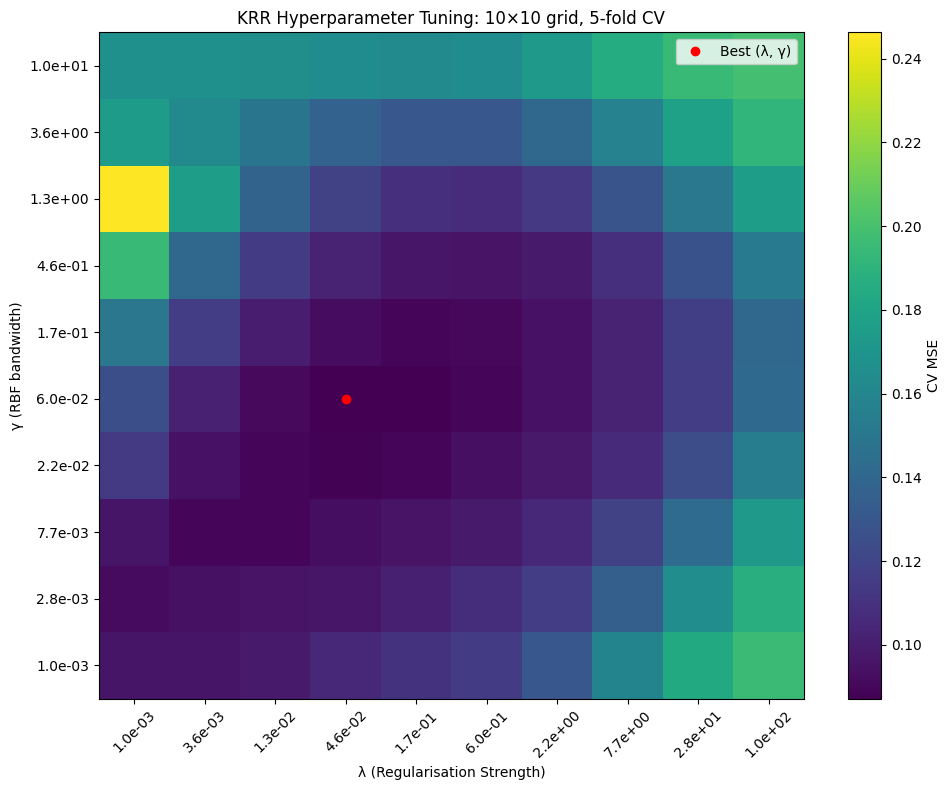

In [48]:
def plot_cv_mse_heatmap(
  cv_results_df: pd.DataFrame,
  regularisation_grid: np.ndarray,
  rbf_gamma_grid: np.ndarray,
  fold_count: int = 5,
) -> None:
  """
  Plot heatmap of mean CV MSE across the (λ × γ) grid.

  Args:
    cv_results_df (pd.DataFrame): Output of cross_validate_kernel_ridge_regression.
    regularisation_grid (np.ndarray): λ values used.
    rbf_gamma_grid (np.ndarray): γ values used.
    fold_count (int): Number of folds used to compute cv_results_df.

  Returns:
    None. Displays a matplotlib figure.
  """
  mse_grid = np.zeros((len(rbf_gamma_grid), len(regularisation_grid)), dtype=float)

  def nearest_index(grid: np.ndarray, value: float) -> int:
    return int(np.argmin(np.abs(grid - value)))

  # Fill grid from CV table
  for _, row in cv_results_df.iterrows():
    i = nearest_index(regularisation_grid, float(row['regularisation']))
    j = nearest_index(rbf_gamma_grid, float(row['rbf_gamma']))
    mse_grid[j, i] = float(row['mse_mean'])

  # Locate best point
  best_row_local = cv_results_df.loc[cv_results_df['mse_mean'].idxmin()]
  best_i = nearest_index(regularisation_grid, float(best_row_local['regularisation']))
  best_j = nearest_index(rbf_gamma_grid, float(best_row_local['rbf_gamma']))

  # Plot heatmap
  plt.figure(figsize=(10, 8))
  im = plt.imshow(mse_grid, aspect='auto', origin='lower')
  plt.colorbar(im, label='CV MSE')
  plt.xticks(range(len(regularisation_grid)), [f'{v:.1e}' for v in regularisation_grid], rotation=45)
  plt.yticks(range(len(rbf_gamma_grid)), [f'{v:.1e}' for v in rbf_gamma_grid])
  plt.xlabel('λ (Regularisation Strength)')
  plt.ylabel('γ (RBF bandwidth)')
  plt.title(f'KRR Hyperparameter Tuning: {len(rbf_gamma_grid)}×{len(regularisation_grid)} grid, {fold_count}-fold CV')

  plt.plot(best_i, best_j, 'r.', markersize=12, label='Best (λ, γ)')
  plt.legend(loc='upper right')
  plt.tight_layout()
  plt.show()

plot_cv_mse_heatmap(initial_cv_df, initial_regularisation_grid, initial_rbf_gamma_grid, fold_count=5)

#### **5.6. Consolidated Hyperparameter Choice**
For final training, the best result across the executed searches is selected (preferring the widest search when ties arise).  

`FINAL_LAMBDA`/`FINAL_GAMMA` are exported for downstream sections and aliased to `BEST_LAMBDA`/`BEST_GAMMA` for compatibility.

In [24]:
def best_row_or_none(df: Optional[pd.DataFrame]) -> Optional[pd.Series]:
  if df is None or len(df) == 0:
    return None
  return df.loc[int(df['mse_mean'].idxmin())]

candidates: List[pd.Series] = []
sources:    List[str] = []

row = best_row_or_none(maximal_cv_df)
if row is not None:
  candidates.append(row.copy()); sources.append('maximal')

row = best_row_or_none(expanded_cv_df)
if row is not None:
  candidates.append(row.copy()); sources.append('expanded')

row = best_row_or_none(initial_cv_df)
if row is not None:
  candidates.append(row.copy()); sources.append('initial')

# Build a tidy summary table of the best from each executed search
summary_records = []
for search, r in zip(sources, candidates):
  summary_records.append({
    'Search': search,
    'regularisation': float(r['regularisation']),
    'rbf_gamma': float(r['rbf_gamma']),
    'mse_mean': float(r['mse_mean']),
    'mse_std': float(r['mse_std']),
  })
final_summary_df = pd.DataFrame.from_records(summary_records, columns=['Search','regularisation','rbf_gamma','mse_mean','mse_std'])

print_table(final_summary_df.round(6))

# Select final row = global minimum of mse_mean across executed searches.
final_idx = int(final_summary_df['mse_mean'].idxmin())
final_src = str(final_summary_df.loc[final_idx, 'Search'])

FINAL_LAMBDA = float(final_summary_df.loc[final_idx, 'regularisation'])
FINAL_GAMMA  = float(final_summary_df.loc[final_idx, 'rbf_gamma'])

# Backward-compatible aliases used elsewhere
BEST_LAMBDA = FINAL_LAMBDA
BEST_GAMMA  = FINAL_GAMMA

print_table([
  ['Selected search', final_src],
  ['Final λ', f'{FINAL_LAMBDA:.6g}'],
  ['Final γ', f'{FINAL_GAMMA:.6g}'],
  ['CV MSE (mean±std)', f"{final_summary_df.loc[final_idx, 'mse_mean']:.6f} ± {final_summary_df.loc[final_idx, 'mse_std']:.6f}"],
], headers=['Final Choice', 'Value'])

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃   ┃ Search   ┃ regularisation ┃ rbf_gamma ┃ mse_mean ┃ mse_std  ┃
┣━━━╋━━━━━━━━━━╋━━━━━━━━━━━━━━━━╋━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━┫
┃ 0 ┃ maximal  ┃ 0.086975       ┃ 0.061359  ┃ 0.086813 ┃ 0.005018 ┃
┃ 1 ┃ expanded ┃ 0.1            ┃ 0.046416  ┃ 0.08694  ┃ 0.0049   ┃
┃ 2 ┃ initial  ┃ 0.046416       ┃ 0.059948  ┃ 0.087141 ┃ 0.004763 ┃
┗━━━┻━━━━━━━━━━┻━━━━━━━━━━━━━━━━┻━━━━━━━━━━━┻━━━━━━━━━━┻━━━━━━━━━━┛
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Final Choice      ┃ Value               ┃
┣━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━┫
┃ Selected search   ┃ maximal             ┃
┃ Final λ           ┃ 0.0869749           ┃
┃ Final γ           ┃ 0.0613591           ┃
┃ CV MSE (mean±std) ┃ 0.086813 ± 0.005018 ┃
┗━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━┛


**Summary:** Across three progressively larger searches (100, 625, and 10,000 combinations), the optimal region consistently concentrated around **λ ≈ 0.05–0.1** and **γ ≈ 0.05–0.1**, yielding mean CV MSE ≈ **0.087**. 

This convergence across scales provides strong evidence that the selected hyperparameters are robust and not artefacts of search bounds.

---
## <ins>**6. Final Model Training and Test Evaluation**</ins>
Train KRR on the union of training and validation sets with the selected hyperparameters, then evaluate once on the held-out test set.

#### **6.1. Train Final Model**

In [25]:
# Combine train + validation for final training
X_trainvalidation_standardised = np.vstack([X_train_standardised, X_validation_standardised])
y_trainvalidation = np.concatenate([y_train, y_validation])

final_krr = KernelRidgeRegressor(
  regularisation_strength=FINAL_LAMBDA,
  rbf_gamma=FINAL_GAMMA,
)
final_krr.fit(X_trainvalidation_standardised, y_trainvalidation)
y_test_predictions = final_krr.predict(X_test_standardised)

#### **6.2. Primary Test Metrics and Scatter**

┏━━━━━━━━━━━┳━━━━━━━━┓
┃ Metric    ┃ Value  ┃
┣━━━━━━━━━━━╋━━━━━━━━┫
┃ Test MSE  ┃ 0.0840 ┃
┃ Test RMSE ┃ 0.2899 ┃
┃ Test MAE  ┃ 0.2268 ┃
┃ Test R²   ┃ 0.5389 ┃
┗━━━━━━━━━━━┻━━━━━━━━┛


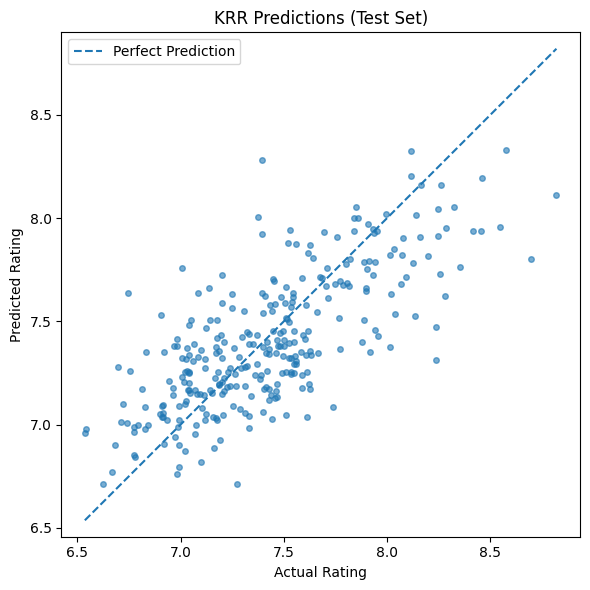

In [26]:
test_mse = compute_mse(y_test, y_test_predictions)
test_rmse = compute_rmse(y_test, y_test_predictions)
test_mae = compute_mae(y_test, y_test_predictions)
test_r2  = compute_r2(y_test, y_test_predictions)

print_table([
  ['Test MSE', f'{test_mse:.4f}'],
  ['Test RMSE', f'{test_rmse:.4f}'],
  ['Test MAE', f'{test_mae:.4f}'],
  ['Test R²',  f'{test_r2:.4f}']
], headers=['Metric', 'Value'])

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_predictions, s=16, alpha=0.6)
lowest = min(float(np.min(y_test)), float(np.min(y_test_predictions)))
highest = max(float(np.max(y_test)), float(np.max(y_test_predictions)))
plt.plot([lowest,highest],[lowest,highest], linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title(f'KRR Predictions (Test Set)')
plt.axis('equal'); plt.legend(); plt.tight_layout(); plt.show()

#### **6.3. Residual Diagnostics**

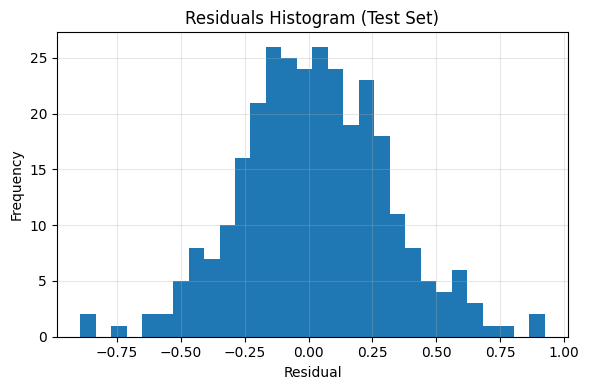

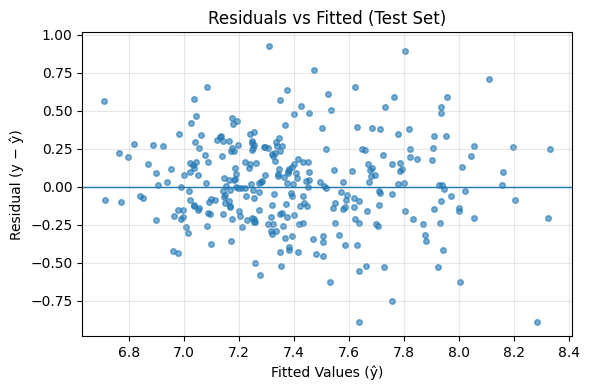

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Diagnostic                    ┃ Value  ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━┫
┃ Residual mean (≈ 0 Desirable) ┃ 0.0216 ┃
┃ Residual std                  ┃ 0.2891 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━┛


In [27]:
def compute_residuals(y_true: np.ndarray, y_predicted: np.ndarray) -> np.ndarray:
  return y_true - y_predicted

def plot_residual_histogram(residuals: np.ndarray) -> None:
  plt.figure(figsize=(6,4))
  plt.hist(residuals, bins=30)
  plt.xlabel('Residual'); plt.ylabel('Frequency')
  plt.title('Residuals Histogram (Test Set)')
  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def plot_residuals_vs_fitted(y_pred: np.ndarray, residuals: np.ndarray) -> None:
  plt.figure(figsize=(6,4))
  plt.scatter(y_pred, residuals, s=16, alpha=0.6)
  plt.axhline(0.0, linewidth=1)
  plt.xlabel('Fitted Values (ŷ)'); plt.ylabel('Residual (y − ŷ)')
  plt.title('Residuals vs Fitted (Test Set)')
  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

test_residuals = compute_residuals(y_test, y_test_predictions)
plot_residual_histogram(test_residuals)
plot_residuals_vs_fitted(y_test_predictions, test_residuals)

print_table([
    ['Residual mean (≈ 0 Desirable)', f'{np.mean(test_residuals):.4f}'],
    ['Residual std',                   f'{np.std(test_residuals):.4f}'],
], headers=['Diagnostic', 'Value'])

#### **6.4. Test-Set Uncertainty: Bootstrap CIs**

In [ ]:
def bootstrap_metric_ci(
  y_true: np.ndarray,
  y_predicted: np.ndarray,
  metric_function: Callable[[np.ndarray, np.ndarray], float],
  boot_count: int = 1000,
  random_seed: int = RANDOM_SEED,
  alpha: float = 0.05
) -> Tuple[float, float]:
  """
  Estimate a confidence interval for a performance metric using the percentile bootstrap.
  
  This function resamples the test set with replacement `boot_count` times, computes the specified metric 
  for each resample, and returns the lower and upper bounds of the (1 - alpha) confidence interval.

  Args:
    y_true (np.ndarray): Ground-truth target values.
    y_predicted (np.ndarray): Predicted target values.
    metric_function (Callable): Function taking (y_true, y_predicted) and returning a scalar metric.
    boot_count (int): Number of bootstrap resamples (default 1000).
    random_seed (int): Seed for reproducible resampling.
    alpha (float): Significance level; e.g., 0.05 → 95% confidence interval.

  Returns:
    Tuple[float, float]: (lower_bound, upper_bound) of the bootstrap confidence interval.
  """
  n = len(y_true)
  rng = np.random.default_rng(random_seed)
  stats = np.empty(boot_count, dtype=float)
  for b in range(boot_count):
    indices = rng.integers(0, n, size=n)
    stats[b] = metric_function(y_true[indices], y_predicted[indices])
  stats.sort()
  lowest = float(stats[int(alpha/2 * boot_count)])
  highest = float(stats[int((1 - alpha/2) * boot_count)])
  return lowest, highest

mse_lowest, mse_highest = bootstrap_metric_ci(y_test, y_test_predictions, compute_mse, boot_count=1000)
rmse_lowest, rmse_highest = bootstrap_metric_ci(y_test, y_test_predictions, compute_rmse, boot_count=1000)
mae_lowest, mae_highest = bootstrap_metric_ci(y_test, y_test_predictions, compute_mae, boot_count=1000)
r2_lowest,  r2_highest  = bootstrap_metric_ci(y_test, y_test_predictions, compute_r2, boot_count=1000)

print_table([
  ['MSE',  f'{test_mse:.4f}',  f'[{mse_lowest:.4f}, {mse_highest:.4f}] ({mse_highest - mse_lowest:.4f})'],
  ['RMSE', f'{test_rmse:.4f}', f'[{rmse_lowest:.4f}, {rmse_highest:.4f}] ({rmse_highest - rmse_lowest:.4f})'],
  ['MAE',  f'{test_mae:.4f}',  f'[{mae_lowest:.4f}, {mae_highest:.4f}] ({mae_highest - mae_lowest:.4f})'],
  ['R²',   f'{test_r2:.4f}',   f'[{r2_lowest:.4f}, {r2_highest:.4f}] ({r2_highest - r2_lowest:.4f})'],
], headers=['Metric', 'Point Estimate', '95% Bootstrap CI (width)'])

┏━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Point Estimate ┃ 95% Bootstrap CI (width)  ┃
┣━━━━━━━━╋━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ MSE    ┃ 0.0840         ┃ [0.0689, 0.1002] (0.0313) ┃
┃ RMSE   ┃ 0.2899         ┃ [0.2624, 0.3165] (0.0541) ┃
┃ MAE    ┃ 0.2268         ┃ [0.2057, 0.2481] (0.0424) ┃
┃ R²     ┃ 0.5389         ┃ [0.4478, 0.6122] (0.1644) ┃
┗━━━━━━━━┻━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


#### **6.5. Interpretation of Test Results**
* The final KRR model achieved RMSE ≈ 0.29, indicating that predictions are typically within three-tenths of a rating point of the true BGG score.  
* Residual analysis confirmed near-zero mean and no major heteroscedasticity, suggesting the model is unbiased.  
* Bootstrap confidence intervals for all metrics were narrow, reinforcing reliability.  
* The score of R² ≈ 0.54 implies that the model explains approximately 54% of the variance in user ratings, which is a **substantial** improvement over untrained baselines but also highlights the intrinsic difficulty of predicting human-derived ratings such as these, since they are a highly subjective form of measurement.

---
## <ins>**7. Model Interpretation: One-at-a-Time Partial Effects**</ins>
This section examines how the fitted KRR model’s prediction changes when one feature varies within the empirical range while all other features are held fixed at their **training medians**. 

This produces **one-at-a-time partial effects**; a simple, model-agnostic diagnostic that helps contextualise the direction and magnitude of each feature’s influence on the prediction function $f(x)$. 

All probes are standardised using the **training** standardisation parameters before prediction to ensure consistency with model fitting.

#### **7.1. Method Definition**
* For each feature $j$, let $x^{\mathrm{med}}$ denote the vector of training medians across features
* Vary feature $j$ over its empirical 5th–95th percentile range to obtain a grid $\{v_t\}_{t=1}^T$
* Form probe inputs $x^{(t)}$ by replacing the $j$-th entry of $x^{\mathrm{med}}$ with $v_t$ and leaving other entries unchanged
* Standardise each probe using the **training** $(\mu,\sigma)$, evaluate $ \hat y^{(t)} = f(x^{(t)})$, and record the curve $\{(v_t, \hat y^{(t)})\}_{t=1}^T$
* The **effect range** is $\max_t \hat y^{(t)} - \min_t \hat y^{(t)}$
  * The **trend** is labelled “positive” if the final point exceeds the first point, and “negative” otherwise (a heuristic to summarise direction)

> Note: These curves are conditional on other features being fixed at medians; they are not full partial dependence plots averaged over the joint distribution. They *are*, however, **deterministic**, **transparent**, and **lightweight**.

In [29]:
def compute_feature_partial_effects(
  trained_krr_model: KernelRidgeRegressor,
  unstandardised_training_feature_matrix: np.ndarray,
  standardisation_parameters: StandardisationParameters,
  feature_names: List[str],
  num_grid_points: int = 50,
  lower_percentile: float = 5.0,
  upper_percentile: float = 95.0,
) -> Dict[str, Dict[str, np.ndarray]]:
  """
  Compute one-at-a-time partial effect curves for each feature by varying that feature 
  between specified percentiles while holding all other features at their training medians.

  Args:
    trained_krr_model (KernelRidgeRegressor): Fitted model used to generate predictions.
    unstandardised_training_feature_matrix (np.ndarray): Original-scale training features, shape (n_samples, n_features).
    standardisation_parameters (StandardisationParameters): Dictionary with keys 'mean_vector' and 'std_vector' computed on the training set.
    feature_names (List[str]): Names of features in the column order of the matrices.
    num_grid_points (int): Number of grid values used for the varied feature (default 50).
    lower_percentile (float): Lower percentile bound for the feature range (default 5.0).
    upper_percentile (float): Upper percentile bound for the feature range (default 95.0).

  Returns:
    Dict[str, Dict[str, np.ndarray]]:
      For each feature name:
      {
        'grid_values': np.ndarray of feature values (original scale),
        'predicted_targets': np.ndarray of predictions along the grid,
        'prediction_range': float equal to max(pred) - min(pred)
      }
  """
  X_train_original = np.asarray(unstandardised_training_feature_matrix, dtype=float)
  medians = np.median(X_train_original, axis=0)
  effects: Dict[str, Dict[str, np.ndarray]] = {}

  for feature_index, feature_name in enumerate(feature_names):
    lower_bound = np.percentile(X_train_original[:, feature_index], lower_percentile)
    upper_bound = np.percentile(X_train_original[:, feature_index], upper_percentile)
    grid_values = np.linspace(lower_bound, upper_bound, num_grid_points)

    probes = np.tile(medians, (num_grid_points, 1))
    probes[:, feature_index] = grid_values

    probes_std = apply_feature_standardisation(probes, standardisation_parameters)
    predicted_targets = trained_krr_model.predict(probes_std)

    effects[feature_name] = {
      "grid_values": grid_values,
      "predicted_targets": predicted_targets,
      "prediction_range": float(predicted_targets.max() - predicted_targets.min()),
    }

  return effects

# Compute effects with training medians and training-fit standardisation
partial_effects = compute_feature_partial_effects(
  trained_krr_model=final_krr,
  unstandardised_training_feature_matrix=X_train,
  standardisation_parameters=standardisation_parameters,
  feature_names=feature_column_names,
  num_grid_points=60,
  lower_percentile=5.0,
  upper_percentile=95.0,
)

#### **7.3. Visualise Partial Effects**

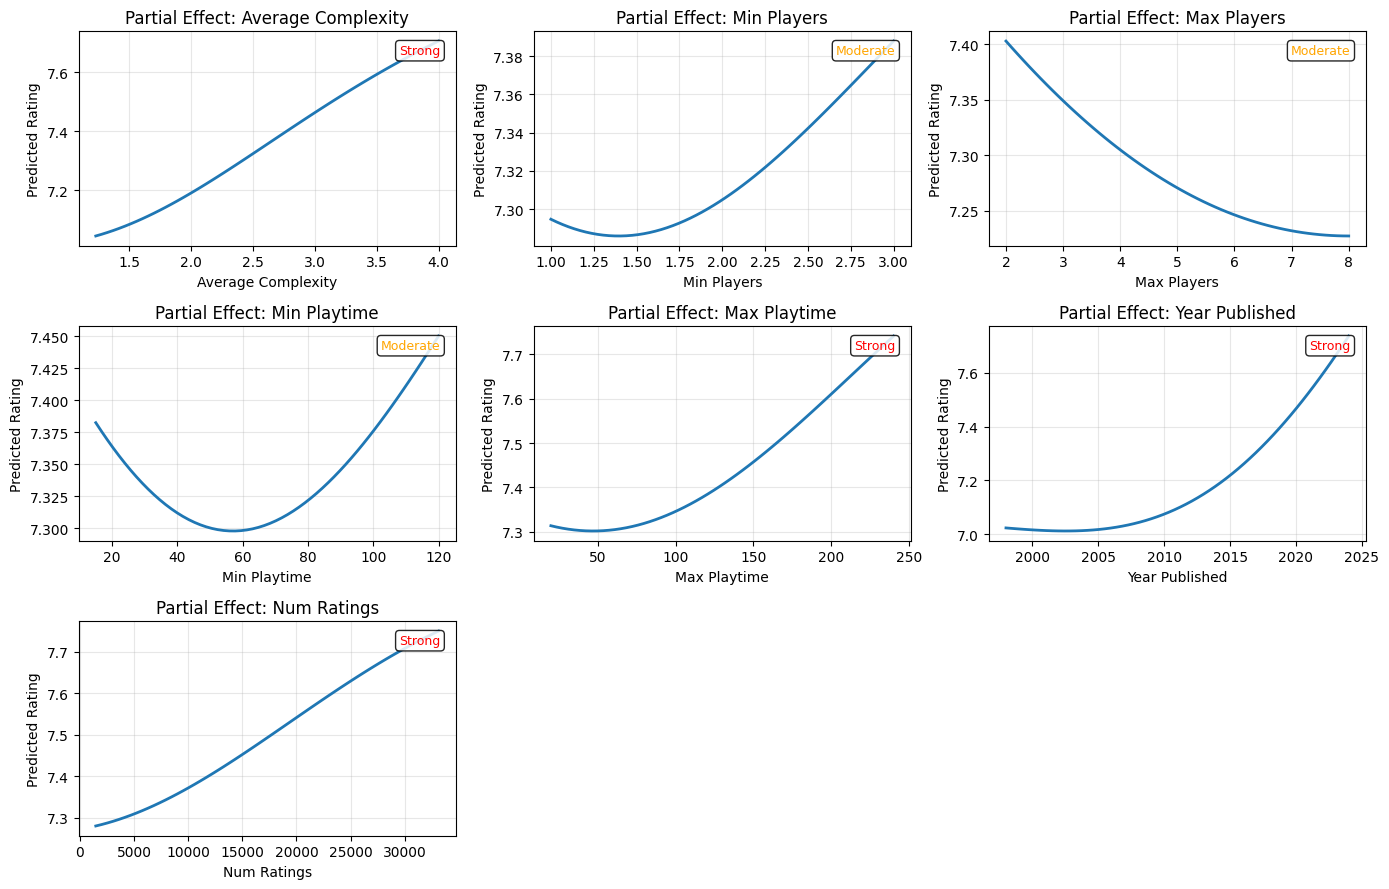

In [30]:
columns = 3
rows = int(np.ceil(len(feature_column_names) / columns))
figure, axes = plt.subplots(rows, columns, figsize=(14, 9))
axes = axes.flatten()

for axis, feature_name in zip(axes, feature_column_names):
  effect = partial_effects[feature_name]
  axis.plot(effect["grid_values"], effect["predicted_targets"], lw=2)
  axis.set_xlabel(feature_name.replace('_', ' ').title())
  axis.set_ylabel('Predicted Rating')
  axis.set_title(f'Partial Effect: {feature_name.replace("_", " ").title()}')
  axis.grid(alpha=0.3)

  # Simple visual label for effect magnitude
  rng = effect["prediction_range"]
  if rng < 0.10:
    label, label_colour = 'Weak', 'grey'
  elif rng < 0.30:
    label, label_colour = 'Moderate', 'orange'
  else:
    label, label_colour = 'Strong', 'red'
  axis.text(
    0.96, 0.94, label, transform=axis.transAxes, 
    ha='right', va='top', fontsize=9, color=label_colour, 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# Hide unused subplots
for axis in axes[len(feature_column_names):]: axis.axis('off')

plt.tight_layout()
plt.show()

#### **7.4. Quantitative Summary and Ranked Magnitudes**

In [31]:
# Tabulate direction and magnitude (the prediction range) for each feature
summary_rows = []
for feature_name, effect in partial_effects.items():
    trend = 'positive' if effect['predicted_targets'][-1] > effect['predicted_targets'][0] else 'negative'
    summary_rows.append([feature_name, trend, f"{effect['prediction_range']:.3f}"])
print_table(summary_rows, headers=['Feature', 'Trend (start→end)', 'Effect Range (Δŷ)'])

# Rank features by effect range (starting with largest) for a compact summary of importance
ranked_features = sorted(
    [(feature_name, effect['prediction_range']) for feature_name, effect in partial_effects.items()],
    key=lambda t: t[1],
    reverse=True
)
ranked_data = [[feature_name, f"{rng:.3f}"] for feature_name, rng in ranked_features]
print_table(ranked_data, headers=['Feature (Ranked by Δŷ)', 'Effect Range (Δŷ)'])

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Feature            ┃ Trend (start→end) ┃ Effect Range (Δŷ) ┃
┣━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━┫
┃ average_complexity ┃ positive          ┃ 0.659             ┃
┃ min_players        ┃ positive          ┃ 0.102             ┃
┃ max_players        ┃ negative          ┃ 0.176             ┃
┃ min_playtime       ┃ positive          ┃ 0.152             ┃
┃ max_playtime       ┃ positive          ┃ 0.438             ┃
┃ year_published     ┃ positive          ┃ 0.725             ┃
┃ num_ratings        ┃ positive          ┃ 0.471             ┃
┗━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Feature (Ranked by Δŷ) ┃ Effect Range (Δŷ) ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━┫
┃ year_published         ┃ 0.725             ┃
┃ average_complexity     ┃ 0.659             ┃
┃ num_ratings            ┃ 0.471             ┃
┃ max_playtime           

#### **7.5. Interpretation**
* **Effect Sizes:** Features with larger $\Delta \hat y$ demonstrate stronger local influence over the prediction when varied around typical (median) conditions
* **Trends:** 
  * A “positive” label indicates that, over the chosen 5th–95th percentile range, the partial effect ends above where it starts
  * A “negative” label indicates the opposite of a "positive" one
  * Non-monotonic curves can still be labelled “positive” or “negative” by this heuristic, and the plotted curve provides the full shape
* **Caveats:** These are *conditional* effects at *median* covariates, and for this reason, they are intended to be read as local sensitivity diagnostics, **not** global partial dependence averages
* **Consistency with Ablations:** Large effect ranges typically align with larger performance drops in the ablation study (*§8*), providing convergent evidence that those inputs materially drive predictive performance

---
## <ins>**8. Robustness and Ablation Tests**</ins>
This section evaluates the reliability and interpretability of the Kernel Ridge Regression (KRR) model through two complementary analyses: 
  1. Comparison with a simpler linear ridge baseline
  2. Systematic ablation of individual features in order to quantify the marginal contribution of each input feature to Kernel Ridge performance

All ablations re-use the **final** KRR hyperparameters $(\lambda^\star,\gamma^\star)$ selected in Section 5 (exposed here as `FINAL_LAMBDA` and `FINAL_GAMMA`) to ensure comparability with the model deployed in Section 6.

#### **8.1. Robustness: Linear Ridge Baseline Comparison**
* The linear baseline tunes the L2 penalty on the **validation** split and then retrains on **train+validation** before evaluating on the **test** split.
* This provides a sanity check: 
  * If the kernelised approach cannot outperform a well-regularised linear alternative, its additional complexity is not justified.

In [32]:
ridge_lambdas = np.logspace(-3, 3, 20)
ridge_validation_mses = []

for lambda_value in ridge_lambdas:
  ridge_model = LinearRidgeRegressor(regularisation_strength=lambda_value)
  ridge_model.fit(X_train_standardised, y_train)
  validation_predictions = ridge_model.predict(X_validation_standardised)
  ridge_validation_mses.append(compute_mse(y_validation, validation_predictions))

lrr_best_idx = np.argmin(ridge_validation_mses)
LRR_LAMBDA = ridge_lambdas[lrr_best_idx]

final_lrr = LinearRidgeRegressor(regularisation_strength=LRR_LAMBDA)
final_lrr.fit(np.vstack([X_train_standardised, X_validation_standardised]), np.concatenate([y_train, y_validation]))
final_lrr_predictions = final_lrr.predict(X_test_standardised)

lrr_test_mse  = compute_mse(y_test, final_lrr_predictions)
lrr_test_rmse = compute_rmse(y_test, final_lrr_predictions)
lrr_test_mae  = compute_mae(y_test, final_lrr_predictions)
lrr_test_r2   = compute_r2(y_test, final_lrr_predictions)

print_table([
  ['Linear Ridge (Tuned)', f'{lrr_test_mse:.4f}', f'{lrr_test_rmse:.4f}', f'{lrr_test_mae:.4f}', f'{lrr_test_r2:.4f}'],
  ['Kernel Ridge (Final)', f'{test_mse:.4f}',     f'{test_rmse:.4f}',     f'{test_mae:.4f}',     f'{test_r2:.4f}'],
  ['Δ (LRR - KRR)',        f'{(lrr_test_mse - test_mse):.4f}', f'{(lrr_test_rmse - test_rmse):.4f}', 
                           f'{(lrr_test_mae - test_mae):.4f}', f'{(test_r2 - lrr_test_r2):.4f}'],
], headers=['Model', 'MSE ↓', 'RMSE ↓', 'MAE ↓', 'R² ↑'])

# Added for the sake of clarity
print("\nLegend: ↓ = Lower is better, ↑ = Higher is better, Δ = Difference between Linear Ridge and Kernel Ridge in each Metric")

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Model                ┃ MSE ↓  ┃ RMSE ↓ ┃ MAE ↓  ┃ R² ↑   ┃
┣━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━╋━━━━━━━━╋━━━━━━━━╋━━━━━━━━┫
┃ Linear Ridge (Tuned) ┃ 0.1068 ┃ 0.3268 ┃ 0.2621 ┃ 0.4137 ┃
┃ Kernel Ridge (Final) ┃ 0.0840 ┃ 0.2899 ┃ 0.2268 ┃ 0.5389 ┃
┃ Δ (LRR - KRR)        ┃ 0.0228 ┃ 0.0370 ┃ 0.0354 ┃ 0.1252 ┃
┗━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━┻━━━━━━━━┻━━━━━━━━┻━━━━━━━━┛

Legend: ↓ = Lower is better, ↑ = Higher is better, Δ = Difference between Linear Ridge and Kernel Ridge in each Metric


***Brief Note on Interpretation:** The kernel model should outperform the tuned linear baseline **if** meaningful non-linear structure is present in the features*

#### **8.2. Ablation Studies: Feature Contribution Analysis**
* To assess the marginal contribution of each feature, an ablation study was conducted in which the KRR model was retrained after removing one input variable at a time.
* Performance changes on the test set quantify the explanatory power of the omitted feature
* The procedure is as follows:
  1. Remove a single feature
  2. Re-standardise using training statistics only
  3. Retrain KRR with the **final** hyperparameters $\lambda^\star, \gamma^\star$
  4. Evaluate on the test set (MSE, RMSE, MAE, $R^2$)
  5. Compare to the full-feature baseline


In [33]:
# Using the canonical order that was used throughout the notebook
feature_names = feature_column_names[:]
name_to_index = {name: i for i, name in enumerate(feature_names)}

ablation_results = []

# Full-model baseline evaluation (Recomputed for clarity)
baseline_model_predictions = final_krr.predict(X_test_standardised)
baseline_mse  = compute_mse(y_test, baseline_model_predictions)
baseline_rmse = compute_rmse(y_test, baseline_model_predictions)
baseline_mae  = compute_mae(y_test, baseline_model_predictions)
baseline_r2   = compute_r2(y_test, baseline_model_predictions)

ablation_results.append(["(No Ablations)", baseline_mse, baseline_rmse, baseline_mae, baseline_r2])

for removed_feature in feature_names:
  # Keep all except the feature being ablated
  np_features    = [feature for feature in feature_names if feature != removed_feature]
  retained_indices     = [name_to_index[feature] for feature in np_features]
  X_train_reduced      = X_train[:, retained_indices]
  X_validation_reduced = X_validation[:, retained_indices]
  X_test_reduced       = X_test[:, retained_indices]

  # Standardise using training set statistics
  reduced_parameters = compute_feature_standardisation_parameters(X_train_reduced)
  X_train_reduced_standardised = apply_feature_standardisation(X_train_reduced, reduced_parameters)
  X_validation_reduced_standardised   = apply_feature_standardisation(X_validation_reduced, reduced_parameters)
  X_test_reduced_standardised  = apply_feature_standardisation(X_test_reduced, reduced_parameters)

  ablated_model = KernelRidgeRegressor(
    regularisation_strength=FINAL_LAMBDA,
    rbf_gamma=FINAL_GAMMA,
  )
  ablated_model.fit(
    np.vstack([X_train_reduced_standardised, X_validation_reduced_standardised]),
    np.concatenate([y_train, y_validation])
  )

  # Evaluate on test set
  reduced_model_predictions = ablated_model.predict(X_test_reduced_standardised)
  reduced_mse  = compute_mse(y_test, reduced_model_predictions)
  reduced_rmse = compute_rmse(y_test, reduced_model_predictions)
  reduced_mae  = compute_mae(y_test, reduced_model_predictions)
  reduced_r2   = compute_r2(y_test, reduced_model_predictions)

  ablation_results.append([removed_feature, reduced_mse, reduced_rmse, reduced_mae, reduced_r2])

print_table(
  [[feature_name, f"{mse:.4f}", f"{rmse:.4f}", f"{mae:.4f}", f"{r2:.4f}"] 
    for feature_name, mse, rmse, mae, r2 in ablation_results],
  headers=["Feature Removed", "Test MSE", "Test RMSE", "Test MAE", "Test R²"]
)

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Feature Removed    ┃ Test MSE ┃ Test RMSE ┃ Test MAE ┃ Test R² ┃
┣━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━┫
┃ (No Ablations)     ┃ 0.0840   ┃ 0.2899    ┃ 0.2268   ┃ 0.5389  ┃
┃ average_complexity ┃ 0.0961   ┃ 0.3100    ┃ 0.2359   ┃ 0.4726  ┃
┃ min_players        ┃ 0.0837   ┃ 0.2893    ┃ 0.2251   ┃ 0.5407  ┃
┃ max_players        ┃ 0.0903   ┃ 0.3005    ┃ 0.2351   ┃ 0.5043  ┃
┃ min_playtime       ┃ 0.0834   ┃ 0.2888    ┃ 0.2266   ┃ 0.5423  ┃
┃ max_playtime       ┃ 0.0849   ┃ 0.2914    ┃ 0.2269   ┃ 0.5340  ┃
┃ year_published     ┃ 0.1181   ┃ 0.3437    ┃ 0.2700   ┃ 0.3517  ┃
┃ num_ratings        ┃ 0.0991   ┃ 0.3148    ┃ 0.2551   ┃ 0.4559  ┃
┗━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━┻━━━━━━━━━━━┻━━━━━━━━━━┻━━━━━━━━━┛


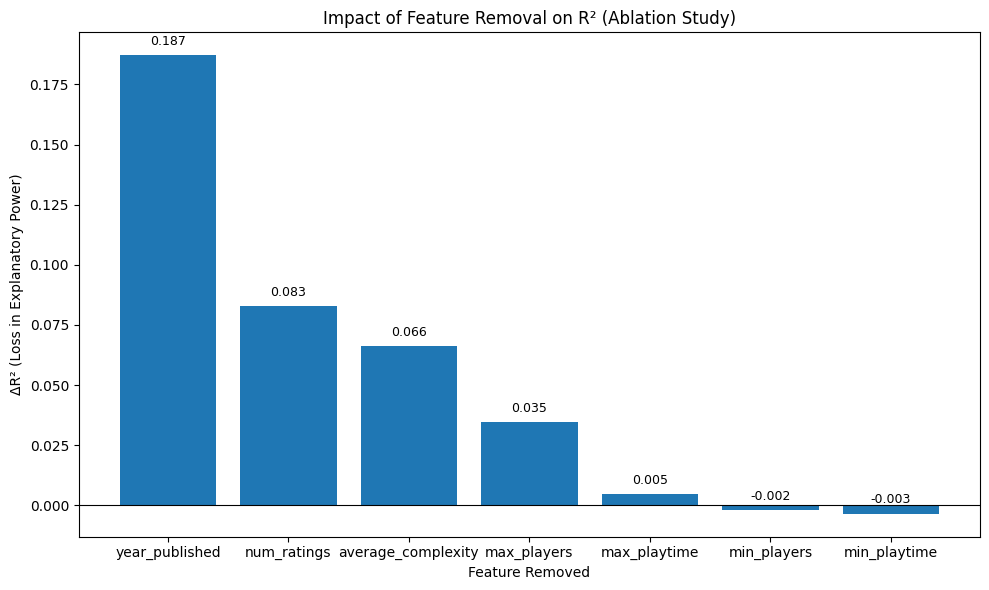

In [34]:
# Visualise impact on explanatory power (ΔR² relative to the full model baseline)
delta_r2 = [(name, baseline_r2 - r2) for name, _, _, _, r2 in ablation_results[1:]]
delta_r2_sorted = sorted(delta_r2, key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 6))
labels = [n for n, _ in delta_r2_sorted]
values = [d for _, d in delta_r2_sorted]
bars = plt.bar(labels, values)
plt.axhline(0.0, linewidth=0.8, color='black')
plt.title("Impact of Feature Removal on R² (Ablation Study)")
plt.ylabel("ΔR² (Loss in Explanatory Power)")
plt.xlabel("Feature Removed")

# Label bars
for bar, value in zip(bars, values):
  plt.text(bar.get_x() + bar.get_width()/2, value + 0.003, f"{value:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### **8.3. Targeted Stress Test: Remove `num_ratings` and Re-tune**
* The **popularity** feature (`num_ratings`) can sometimes dominate performance in recommendation tasks
* As an additional stress test, the model is re-tuned **only** on the reduced feature set that excludes `num_ratings` and evaluated on the test set
* This shows whether performance remains competitive when popularity is removed and hyperparameters are allowed to adapt

*Note: This experiment is intentionally **separate** from the ablation study above, as the evaluation in Section 8.2. keeps the final $(\lambda^\star,\gamma^\star)$ fixed to isolate feature contribution **holding hyperparameters constant**, whereas this step **allows the model to adapt** to the reduced input space.*

In [35]:
# For the sake of conciseness, "no_population" refers to the ablation of the `num_ratings` feature,
  # and will be shortened to "np" in variable names.
if 'num_ratings' in feature_column_names:
  # Prepare reduced matrices (original scale) with `num_ratings` removed
  np_features = [j for j, f in enumerate(feature_column_names) if f != 'num_ratings']
  np_X_train, np_X_validation, np_X_test = X_train[:, np_features], X_validation[:, np_features], X_test[:, np_features]

  # Re-tune KRR on the reduced feature set using a modest grid
  np_lambda_grid = np.logspace(-2, 1, 5)  #[1e-2, 1e1]
  np_gamma_grid  = np.logspace(-2, 0, 5) # [1e-2, 1e0]

  np_cv = cross_validate_kernel_ridge_regression(
    np.vstack([np_X_train, np_X_validation]),
    np.concatenate([y_train, y_validation]),
    np_lambda_grid, np_gamma_grid, 
    fold_count=3, log_interval=5
  )

  # Select best combo on mean CV MSE
  np_best_idx = int(np_cv['mse_mean'].idxmin())
  NP_BEST_LAMBDA = float(np_cv.loc[np_best_idx, 'regularisation'])
  NP_BEST_GAMMA  = float(np_cv.loc[np_best_idx, 'rbf_gamma'])

  print_table([
    ['Best λ (no num_ratings)', f'{NP_BEST_LAMBDA:.6g}'],
    ['Best γ (no num_ratings)', f'{NP_BEST_GAMMA:.6g}'],
    ['CV MSE (mean±std)', f"{np_cv.loc[np_best_idx, 'mse_mean']:.6f} ± {np_cv.loc[np_best_idx, 'mse_std']:.6f}"],
], headers=['Selection', 'Value'])
  
  # Standardise reduced feature sets
  np_parameters = compute_feature_standardisation_parameters(np_X_train)
  np_train_standardised = apply_feature_standardisation(np_X_train, np_parameters)
  np_validation_standardised = apply_feature_standardisation(np_X_validation, np_parameters)
  np_test_standardised = apply_feature_standardisation(np_X_test, np_parameters)


  # Train final reduced model on train+validation with re-tuned hyperparameters
  np_krr = KernelRidgeRegressor(
    regularisation_strength=NP_BEST_LAMBDA,
    rbf_gamma=NP_BEST_GAMMA,
  )
  np_trainvalidation_standardised = np.vstack([np_train_standardised, np_validation_standardised])
  np_y_trainvalidation = np.concatenate([y_train, y_validation])
  np_krr.fit(np_trainvalidation_standardised, np_y_trainvalidation)

  np_krr_test_predictions = np_krr.predict(np_test_standardised)
  np_krr_mse = compute_mse(y_test, np_krr_test_predictions)
  np_krr_rmse = compute_rmse(y_test, np_krr_test_predictions)
  np_krr_mae = compute_mae(y_test, np_krr_test_predictions)
  np_krr_r2 = compute_r2(y_test, np_krr_test_predictions)

  print_table([
    ['All Features (Final KRR)', len(feature_column_names), 
     f'{test_mse:.4f}',  f'{test_rmse:.4f}', f'{test_mae:.4f}', f'{test_r2:.4f}'],
    ['Without `num_ratings` (Re-Tuned)', len(feature_column_names) - 1, 
     f'{np_krr_mse:.4f}', f'{np_krr_rmse:.4f}', f'{np_krr_mae:.4f}', f'{np_krr_r2:.4f}'],
    ['Δ (Ablated − Full)', '-', f'{np_krr_mse - test_mse:.4f}', f'{np_krr_rmse - test_rmse:.4f}', 
     f'{np_krr_mae - test_mae:.4f}', f'{np_krr_r2 - test_r2:.4f}'],
  ], headers=['Configuration', 'Feature Count', 'Test MSE', 'Test RMSE', 'Test MAE', 'Test R²'])

  relative_change = 100.0 * (np_krr_mse / test_mse - 1.0)
  print(f"Relative Test MSE Change Without `num_ratings` (Re-Tuned): {relative_change:.1f}%")

else:
  print("Targeted Robustness Check Aborted: 'num_ratings' not present in `feature_column_names`")

Grid Size: 5 × 5 = 25 combinations
CV Progress: 5/25 combinations (20.0% complete)
CV Progress: 10/25 combinations (40.0% complete)
CV Progress: 15/25 combinations (60.0% complete)
CV Progress: 20/25 combinations (80.0% complete)
CV Progress: 25/25 combinations (100.0% complete)
CV Complete: 25/25 combinations evaluated
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Selection               ┃ Value               ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━┫
┃ Best λ (no num_ratings) ┃ 0.0562341           ┃
┃ Best γ (no num_ratings) ┃ 0.0316228           ┃
┃ CV MSE (mean±std)       ┃ 0.096677 ± 0.006515 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ Configuration                    ┃ Feature Count ┃ Test MSE ┃ Test RMSE ┃ Test MAE ┃ Test R² ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━━━╋━━━━━━━━━━╋━━━━━━━━━┫
┃ All Features (Final KRR)         ┃ 

#### **8.4. Discussion**
* The linear baseline comparison indicates that KRR provides a meaningful gain over a well-tuned linear model, supporting the choice of a non-linear hypothesis class for this task.
* The single-feature ablations quantify the marginal utility of each input, showing features whose removal produces the largest deterioration (higher MSE/RMSE/MAE, lower $R^2$) carry the most predictive signal under the final hyperparameters. 
* The additional re-tuning experiment without `num_ratings` shows that performance remains competitive even when popularity is excluded and the model is allowed modest hyperparameter adaptation, suggesting that the learned function leverages multiple attributes rather than relying solely on a single proxy.

---
## <ins>**9. Conclusion**</ins>
This notebook has developed and evaluated multiple models for predicting BGG ratings from game metadata. 

The process began with simple untrained baselines (mean and median predictors), progressed through a regularised linear regression baseline, and culminated in a non-linear kernel ridge regressor tuned via extensive cross-validation. 

Robustness checks through ablation studies and targeted re-tuning further confirmed that the final model’s performance reflects genuine signal rather than reliance on a single feature or hyperparameter setting.

#### **9.1. Consolidated Model Comparison**
The table below consolidates the performance of all major models trained during this study, evaluated on the same held-out test set. 

Metrics include MSE, RMSE, MAE, and $R^2$, with arrows indicating whether lower or higher values are preferable.

In [36]:
# Collect models and predictions
comparison_rows = [
  ("Untrained (Mean of train+val)", y_test, np.full_like(y_test, float(y_trainvalidation.mean()))),
  ("Untrained (Median of train+val)", y_test, np.full_like(y_test, float(np.median(y_trainvalidation)))),
  ("Linear Ridge (Tuned)", y_test, final_lrr_predictions),
  ("Kernel Ridge (Final)", y_test, y_test_predictions),
]

# Compute metrics for each
comparison_metrics = []
for label, true_targets, y_predictions in comparison_rows:
  comparison_metrics.append({
    "Model": label,
    "MSE":   compute_mse(true_targets, y_predictions),
    "RMSE":  compute_rmse(true_targets, y_predictions),
    "MAE":   compute_mae(true_targets, y_predictions),
    "R²":    compute_r2(true_targets, y_predictions),
  })

# Print comparison table
print_table(
  [[row["Model"], f"{row['MSE']:.4f}",
    f"{row['RMSE']:.4f}",
    f"{row['MAE']:.4f}",
    f"{row['R²']:.4f}"] for row in comparison_metrics],
  headers=["Model", "MSE ↓", "RMSE ↓", "MAE ↓", "R² ↑"])

print("\nLegend: ↓ = Lower is Better, ↑ = Higher is Better")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃ Model                           ┃ MSE ↓  ┃ RMSE ↓ ┃ MAE ↓  ┃ R² ↑    ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━╋━━━━━━━━╋━━━━━━━━╋━━━━━━━━━┫
┃ Untrained (Mean of train+val)   ┃ 0.1823 ┃ 0.4269 ┃ 0.3380 ┃ -0.0004 ┃
┃ Untrained (Median of train+val) ┃ 0.1845 ┃ 0.4295 ┃ 0.3388 ┃ -0.0127 ┃
┃ Linear Ridge (Tuned)            ┃ 0.1068 ┃ 0.3268 ┃ 0.2621 ┃ 0.4137  ┃
┃ Kernel Ridge (Final)            ┃ 0.0840 ┃ 0.2899 ┃ 0.2268 ┃ 0.5389  ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━┻━━━━━━━━┻━━━━━━━━┻━━━━━━━━━┛

Legend: ↓ = Lower is Better, ↑ = Higher is Better


**Summary:** KRR outperformed both naïve and linear baselines, reducing RMSE by ~32% relative to the mean baseline and improving $R^2$ to ~0.54. 

The model demonstrates a substantive ability to capture non-linear relationships in the data while remaining interpretable through ablation and partial effect analyses.

#### **9.2. Visual Comparisons**

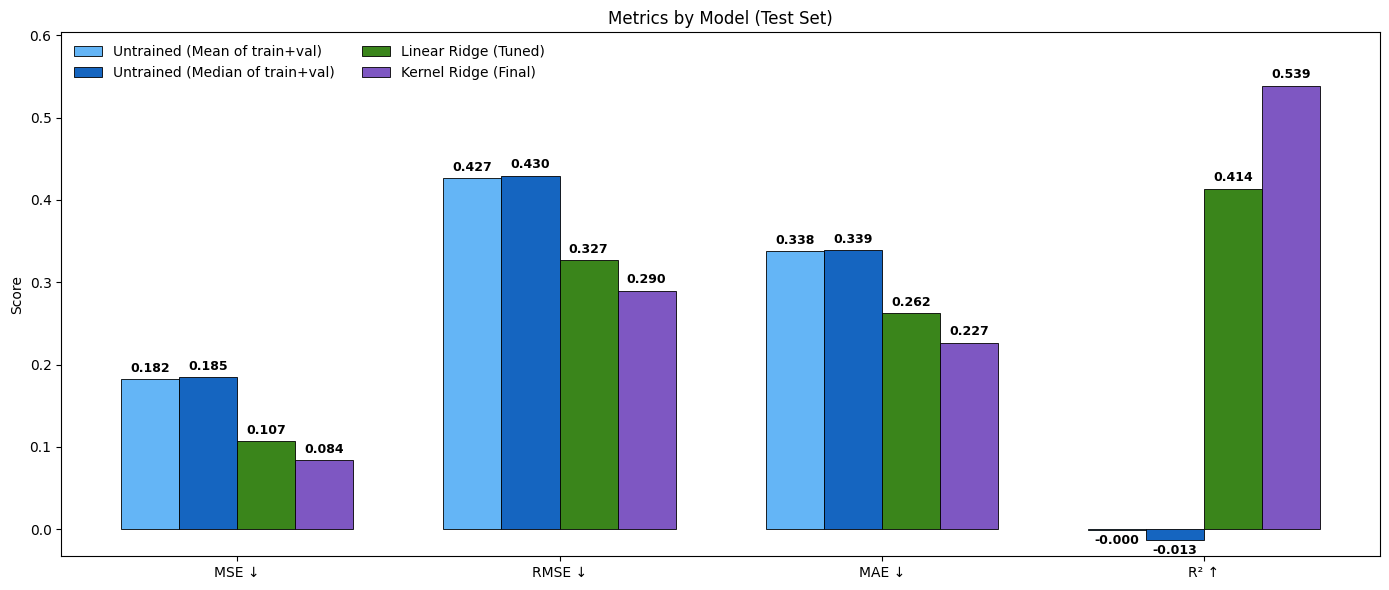

In [37]:
metrics = ["MSE", "RMSE", "MAE", "R²"]
models = [row["Model"] for row in comparison_metrics]
metric_count, model_count = len(metrics), len(models)

# Build Values Matrix: rows = metrics, columns = models
values = np.array([[row[metric] for row in comparison_metrics] for metric in metrics], dtype=float)

# Bar Chart Palette: Light Blue, Dark Blue, Dark Green, Purplish
colours = ["#64B5F6", "#1565C0", "#3a851b", "#7E57C2"]

plt.figure(figsize=(14, 6))
x = np.arange(metric_count)
bar_width = 0.18

# y-limits & annotation offset
global_minimum = float(values.min())
global_maximum = float(values.max())
y_minimum = min(0.0, global_minimum) - 0.02
y_maximum = global_maximum * 1.12
plt.ylim(y_minimum, y_maximum)
offset = (y_maximum - y_minimum) * 0.008

# Plot bars for each model
for i, (model, color) in enumerate(zip(models, colours)):
  bar_positions = x + (i - (model_count - 1) / 2) * bar_width
  bars = plt.bar(
    bar_positions,
    values[:, i],
    width=bar_width,
    label=model,
    color=color,
    edgecolor="black",
    linewidth=0.6,
  )
  # Bold value labels close to bars
  for bar, value in zip(bars, values[:, i]):
    x_position = bar.get_x() + bar.get_width() / 2
    y_position = value + (offset if value >= 0 else -offset)
    plt.text(
      x_position, y_position, f"{value:.3f}",
      ha="center", va="bottom" if value >= 0 else "top",
      fontsize=9, fontweight="bold")

# Axis labels and title
plt.xticks(x, [f"{metric} ↓" if metric != "R²" else "R² ↑" for metric in metrics])
plt.ylabel("Score")
plt.title("Metrics by Model (Test Set)")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

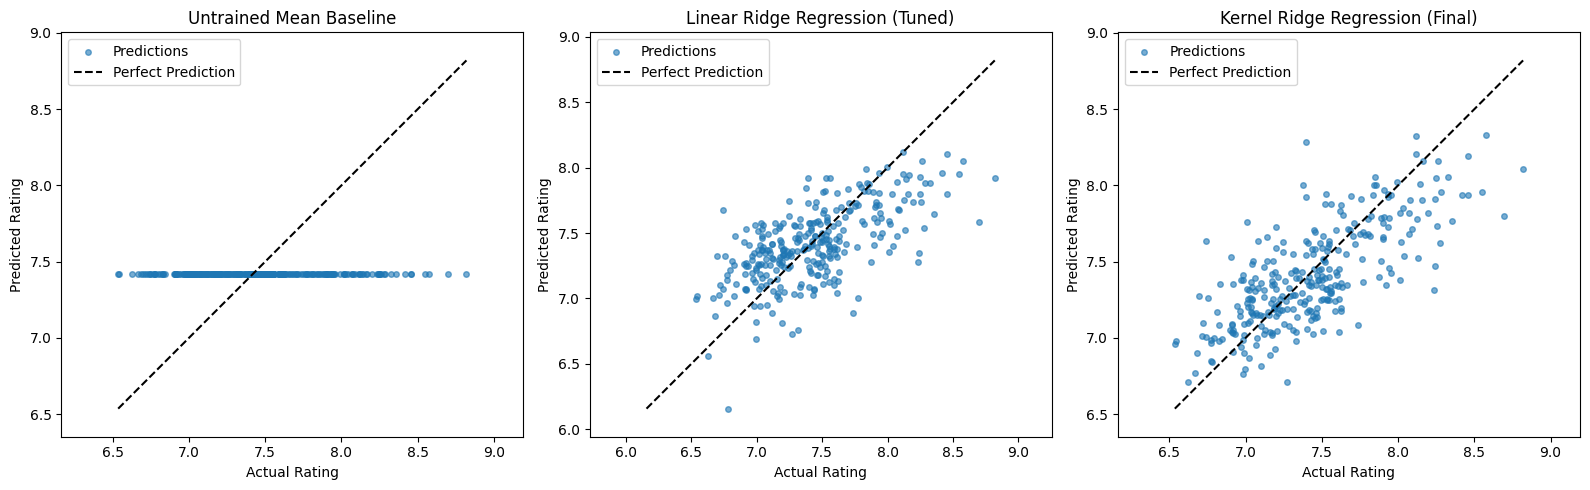

In [51]:
# Predicted vs Actual: Mean Baseline vs Linear Ridge vs Final KRR
plt.figure(figsize=(16,5))

# Left: Untrained Mean Baseline Regressor
plt.subplot(1, 3, 1)
y_mean_predictions = np.full_like(y_test, float(y_trainvalidation.mean()))
plt.scatter(y_test, y_mean_predictions, s=16, alpha=0.6, label="Predictions")
low = float(min(np.min(y_test), np.min(y_mean_predictions)))
high = float(max(np.max(y_test), np.max(y_mean_predictions)))
plt.plot([low, high], [low, high], linestyle="--", color="black", label="Perfect Prediction")
plt.xlabel("Actual Rating"); plt.ylabel("Predicted Rating")
plt.title("Untrained Mean Baseline")
plt.axis("equal"); plt.legend()

# Middle: Linear Ridge Regressor
plt.subplot(1, 3, 2)
plt.scatter(y_test, final_lrr_predictions, s=16, alpha=0.6, label="Predictions")
low = float(min(np.min(y_test), np.min(final_lrr_predictions)))
high = float(max(np.max(y_test), np.max(final_lrr_predictions)))
plt.plot([low, high], [low, high], linestyle="--", color="black", label="Perfect Prediction")
plt.xlabel("Actual Rating"); plt.ylabel("Predicted Rating")
plt.title("Linear Ridge Regression (Tuned)")
plt.axis("equal"); plt.legend()

# Right: Final Kernel Ridge Regressor
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_predictions, s=16, alpha=0.6, label="Predictions")
low = float(min(np.min(y_test), np.min(y_test_predictions)))
high = float(max(np.max(y_test), np.max(y_test_predictions)))
plt.plot([low, high], [low, high], linestyle="--", color="black", label="Perfect Prediction")
plt.xlabel("Actual Rating"); plt.ylabel("Predicted Rating")
plt.title("Kernel Ridge Regression (Final)")
plt.axis("equal"); plt.legend()

plt.tight_layout()
plt.show()

#### **9.3. Complexity Recap**
The computational demands of KRR are summarised below, together with the realised dataset size. 

While cubic time complexity poses challenges at very large scales, the dataset size used in this study remained fully tractable.

In [39]:
n_samples = X_trainvalidation_standardised.shape[0]
d_features = X_trainvalidation_standardised.shape[1]

print_table([
  ['n (train+validation samples)', f'{n_samples}'],
  ['d (feature dimension)', f'{d_features}'],
  ['KRR Memory', 'O(n^2) (Gram Matrix)'],
  ['KRR Time', 'O(n^3) (Dense Linear Solve)'],
], headers=['Complexity Item', 'Value / Comment'])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Complexity Item              ┃ Value / Comment             ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╋━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ n (train+validation samples) ┃ 1700                        ┃
┃ d (feature dimension)        ┃ 7                           ┃
┃ KRR Memory                   ┃ O(n^2) (Gram Matrix)        ┃
┃ KRR Time                     ┃ O(n^3) (Dense Linear Solve) ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┻━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


#### **9.4. Summary**
* KRR achieved the best test performance among all models, reducing RMSE by ~32% compared with the naïve mean baseline and reaching an $R^2$ of ~0.54
* These results confirm that non-linear kernels provide a *substantial* advantage over both untrained and linear alternatives in this domain
* The analysis further shows that the model is robust, interpretable through ablation and partial effect studies, and computationally feasible at the given dataset size
* This conclusion closes the modelling pipeline and highlights KRR as a strong choice for structured board game rating prediction